In [57]:
import pandas as pd
import numpy as np
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [3]:
columns_filtered = [
    'CoC Number', 
    'CoC Name', 
    'CoC Category', 
    'Count Types', 
    'Overall Homeless', 
    'Overall Chronically Homeless',
    'Unsheltered Homeless', 
    'Sheltered Total Homeless',
    'Sheltered ES Homeless', 
    'Sheltered TH Homeless', 
    'Sheltered SH Homeless'
]

columns_filtered_2 = [
    'CoC Number', 
    'CoC Name', 
    'Count Types', 
    'Overall Homeless', 
    'Overall Chronically Homeless',
    'Unsheltered Homeless', 
    'Sheltered Total Homeless',
    'Sheltered ES Homeless', 
    'Sheltered TH Homeless', 
    'Sheltered SH Homeless'
]

columns_filtered_3 = [
    'CoC Number', 
    'CoC Name', 
    'Count Types', 
    'Overall Homeless', 
    'Overall Chronically Homeless Individuals',
    'Unsheltered Homeless', 
    'Sheltered Total Homeless',
    'Sheltered ES Homeless', 
    'Sheltered TH Homeless', 
    'Sheltered SH Homeless'
]


In [4]:
medianRentDF2024 = pd.read_csv('rent2024.csv')
medianRentDF2023 = pd.read_csv('rent2023.csv')
medianRentDF2022 = pd.read_csv('rent2022.csv')
medianRentDF2021 = pd.read_csv('rent2021.csv')
medianRentDF2020 = pd.read_csv('rent2020.csv')
medianRentDF2019 = pd.read_csv('rent2019.csv')
medianRentDF2018 = pd.read_csv('rent2018.csv')
medianRentDF2017 = pd.read_csv('rent2017.csv')
medianRentDF2016 = pd.read_csv('rent2016.csv')
medianRentDF2015 = pd.read_csv('rent2015.csv')
medianRentDF2014 = pd.read_csv('rent2014.csv')

In [5]:
medianRentDF_columns_filtered = [
    'NAME', 'B25111_001E'
]

In [6]:
# List of years to process
years = range(2024, 2013, -1)

for year in years:
    df_name = f'medianRentDF{year}'
    
    if df_name in locals():
        # Grab the current dataframe
        df = locals()[df_name]
        
        # Filter columns
        df = df[medianRentDF_columns_filtered]
        
        # Dropped the US row and the naming row (rows 0 and 1)
        df = df.drop([0, 1])
        
        # Renamed the rent column to include the specific year
        df = df.rename(columns={'B25111_001E': f'Median Rent {year}'})
        
        # Reset index
        df = df.reset_index(drop=True)
        
        # Saved it back to the variable name
        locals()[df_name] = df
    else:
        print(f"{df_name} not found in memory.")


In [7]:
medianRentDF2014.head()

,NAME,Median Rent 2014
0,"Autauga County, Alabama",876
1,"Baldwin County, Alabama",882
2,"Barbour County, Alabama",608
3,"Bibb County, Alabama",610
4,"Blount County, Alabama",609


In [8]:
medianRentDF2014.shape

(3220, 2)

In [9]:
state_to_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO',
    'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH',
    'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT',
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY',
    'District of Columbia': 'DC'
}


In [10]:
# Defined the logic for the array/list conversion
def split_codes(code_string):
    if pd.isna(code_string): return []
    return [c.strip() for c in str(code_string).split('/')]

# Read the file directly into 'data'
data = pd.read_csv(
    'coc-county-mapping - Sheet4.csv', 
    header=None, 
    names=['County', 'CoC-Code', 'CoC-Name'],
    converters={'CoC-Code': split_codes}
)

data.head()

,County,CoC-Code,CoC-Name
0,Baldwin County,[AL-501],NaN
1,Calhoun County,[AL-505],NaN
2,Cullman County,[AL-507],NaN
3,DeKalb County,[AL-505],NaN
4,Elmore County,[AL-504],NaN


In [11]:
data.shape

(811, 3)

In [12]:
homelessDF2024 = pd.read_csv('2007-2024-PIT-Counts-by-CoC.xlsx - 2024.csv')
homelessDF2024 = homelessDF2024[columns_filtered]
homelessDF2023 = pd.read_csv('2007-2024-PIT-Counts-by-CoC.xlsx - 2023.csv')
homelessDF2023 = homelessDF2023[columns_filtered_2]
homelessDF2022 = pd.read_csv('2007-2024-PIT-Counts-by-CoC.xlsx - 2022.csv')
homelessDF2022 = homelessDF2022[columns_filtered_2]
homelessDF2021 = pd.read_csv('2007-2024-PIT-Counts-by-CoC.xlsx - 2021.csv')
homelessDF2021 = homelessDF2021[columns_filtered_2]
homelessDF2020 = pd.read_csv('2007-2024-PIT-Counts-by-CoC.xlsx - 2020.csv')
homelessDF2020 = homelessDF2020[columns_filtered_2]
homelessDF2019 = pd.read_csv('2007-2024-PIT-Counts-by-CoC.xlsx - 2019.csv')
homelessDF2019 = homelessDF2019[columns_filtered_2]
homelessDF2018 = pd.read_csv('2007-2024-PIT-Counts-by-CoC.xlsx - 2018.csv')
homelessDF2018 = homelessDF2018[columns_filtered_2]
homelessDF2017 = pd.read_csv('2007-2024-PIT-Counts-by-CoC.xlsx - 2017.csv')
homelessDF2017 = homelessDF2017[columns_filtered_2]
homelessDF2016 = pd.read_csv('2007-2024-PIT-Counts-by-CoC.xlsx - 2016.csv')
homelessDF2016 = homelessDF2016[columns_filtered_2]
homelessDF2015 = pd.read_csv('2007-2024-PIT-Counts-by-CoC.xlsx - 2015.csv')
homelessDF2015 = homelessDF2015[columns_filtered_2]
homelessDF2014 = pd.read_csv('2007-2024-PIT-Counts-by-CoC.xlsx - 2014.csv')
homelessDF2014 = homelessDF2014[columns_filtered_2]


In [13]:
homelessDF2024.head()

,CoC Number,CoC Name,CoC Category,Count Types,Overall Homeless,Overall Chronically Homeless,Unsheltered Homeless,Sheltered Total Homeless,Sheltered ES Homeless,Sheltered TH Homeless,Sheltered SH Homeless
0,WY-500,Wyoming Statewide CoC,Largely Rural CoC,Sheltered and Unsheltered Count,501,126,89,412,259,153,0
1,WV-508,West Virginia Balance of State CoC,Largely Rural CoC,Sheltered and Unsheltered Count,"1,037",217,534,503,444,59,0
2,WV-503,"Charleston/Kanawha, Putnam, Boone, Clay Counties CoC",Largely Suburban CoC,Sheltered and Unsheltered Count,335,81,142,193,178,15,0
3,WV-501,"Huntington/Cabell, Wayne Counties CoC",Other Largely Urban CoC,Sheltered and Unsheltered Count,278,32,70,208,201,0,7
4,WV-500,Wheeling/Weirton Area CoC,Largely Rural CoC,Sheltered and Unsheltered Count,129,56,42,87,68,19,0


In [14]:
homelessDF2024.shape

(386, 11)

In [15]:
povertyDF2024 = pd.read_csv('poverty2024.csv', dtype=str)
povertyDF2023 = pd.read_csv('poverty2023.csv', dtype=str)
povertyDF2022 = pd.read_csv('poverty2022.csv', dtype=str)
povertyDF2021 = pd.read_csv('poverty2021.csv', dtype=str)
povertyDF2020 = pd.read_csv('poverty2020.csv', dtype=str)
povertyDF2019 = pd.read_csv('poverty2019.csv', dtype=str)
povertyDF2018 = pd.read_csv('poverty2018.csv', dtype=str)
povertyDF2017 = pd.read_csv('poverty2017.csv', dtype=str)
povertyDF2016 = pd.read_csv('poverty2016.csv', dtype=str)
povertyDF2015 = pd.read_csv('poverty2015.csv', dtype=str)
povertyDF2014 = pd.read_csv('poverty2014.csv', dtype=str)

In [16]:
# Defined the years we want to process
years = range(2024, 2013, -1)

for year in years:
    df_name = f'povertyDF{year}'
    
    if df_name in locals():
        # Grab the dataframe from memory
        df = locals()[df_name]
        
        # Selected only the columns we need + the NAME for joining
        cols_to_keep = ['S1701_C01_038E', 'S1701_C02_001E', 'S1701_C01_001E', 'NAME']
        df = df[cols_to_keep].copy()
        
        # Renamde columns to include the specific year
        df = df.rename(columns={
            'S1701_C01_038E': f'ttl_extreme_poverty {year}',
            'S1701_C02_001E': f'ttl_poverty {year}',
            'S1701_C01_001E': f'ttl_population {year}'
        })
        
        # Dropped the US/Header rows (0 and 1) and reset index
        df = df.drop([0, 1]).reset_index(drop=True)
        
        # Saved the cleaned version back to its variable name
        locals()[df_name] = df
        
    else:
        print(f"{df_name} not found in memory. Skipping.")

# Check a random year to make sure it worked
povertyDF2015.head()



,ttl_extreme_poverty 2015,ttl_poverty 2015,ttl_population 2015,NAME
0,2623,7057,54793,"Autauga County, Alabama"
1,10974,25798,192355,"Baldwin County, Alabama"
2,3514,6421,24024,"Barbour County, Alabama"
3,1196,3488,20767,"Bibb County, Alabama"
4,3801,9552,57126,"Blount County, Alabama"


In [17]:
vacancyDF2024 = pd.read_csv('vacancy2024.csv')
vacancyDF2023 = pd.read_csv('vacancy2023.csv')
vacancyDF2022 = pd.read_csv('vacancy2022.csv')
vacancyDF2021 = pd.read_csv('vacancy2021.csv')
vacancyDF2020 = pd.read_csv('vacancy2020.csv')
vacancyDF2019 = pd.read_csv('vacancy2019.csv')
vacancyDF2018 = pd.read_csv('vacancy2018.csv')
vacancyDF2017 = pd.read_csv('vacancy2017.csv')
vacancyDF2016 = pd.read_csv('vacancy2016.csv')
vacancyDF2015 = pd.read_csv('vacancy2015.csv')
vacancyDF2014 = pd.read_csv('vacancy2014.csv')

In [18]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

final_df = data.copy()

# Clean + split + explode CoC codes
final_df['CoC-Code'] = final_df['CoC-Code'].astype(str).str.replace(r"[\[\]\'\"\s]", "", regex=True)
final_df['CoC-Code'] = final_df['CoC-Code'].str.split(',')
final_df = final_df.explode('CoC-Code').reset_index(drop=True)

# derive state AFTER explode
final_df['State'] = final_df['CoC-Code'].str[:2]

# base for homeless merge
exploded_base = final_df[['County', 'CoC-Code', 'State']].copy()

poverty_metrics = ['ttl_extreme_poverty', 'ttl_poverty', 'ttl_population']

base_homeless_cols = [
    'Overall Homeless', 'Overall Chronically Homeless', 'Unsheltered Homeless', 
    'Sheltered Total Homeless', 'Sheltered ES Homeless', 'Sheltered TH Homeless', 
    'Sheltered SH Homeless'
]



for year in years:
    year_suffix = f" {year}"
    
    # Homeless Data (per CoC)
    homeless_df_name = f'homelessDF{year}'

    if homeless_df_name in locals() or homeless_df_name in globals():
        hdf = locals().get(homeless_df_name, globals().get(homeless_df_name)).copy()
        
        if 'CoC Number' in hdf.columns:
            hdf['CoC Number'] = hdf['CoC Number'].astype(str).str.replace(r"[\[\]\'\"\s]", "", regex=True)
            
            for col in base_homeless_cols:
                if col in hdf.columns:
                    hdf[col] = pd.to_numeric(
                        hdf[col].astype(str).str.replace(',', ''),
                        errors='coerce'
                    )
            
            merged_hdf = pd.merge(
                exploded_base,
                hdf,
                left_on='CoC-Code',
                right_on='CoC Number',
                how='left'
            )
            
            # Fix state column by handling suffix issue
            if 'State_x' in merged_hdf.columns:
                merged_hdf['State'] = merged_hdf['State_x']
            elif 'State' not in merged_hdf.columns and 'State_y' in merged_hdf.columns:
                merged_hdf['State'] = merged_hdf['State_y']
            
            valid_cols = [c for c in base_homeless_cols if c in hdf.columns]
            
            merged_hdf = merged_hdf[['County', 'State', 'CoC-Code'] + valid_cols]
            
            rename_dict = {col: f"{col} {year}" for col in valid_cols}
            merged_hdf = merged_hdf.rename(columns=rename_dict)
            
            final_df = pd.merge(
                final_df,
                merged_hdf,
                on=['County', 'State', 'CoC-Code'],
                how='left'
            )
        else:
            print(f"'CoC Number' column not found in {homeless_df_name}.")
    else:
        print(f"Dataframe '{homeless_df_name}' not found. Skipping.")
    

    # Rent data
    rent_df_name = f'medianRentDF{year}'

    if rent_df_name in locals() or rent_df_name in globals():
        rent_df = locals().get(rent_df_name, globals().get(rent_df_name)).copy()
        rent_col = f'Median Rent {year}'
        
        if rent_col in rent_df.columns:
            rent_df['County'] = rent_df['NAME'].str.split(',').str[0].str.strip()
            rent_df['State_Name'] = rent_df['NAME'].str.split(',').str[1].str.strip()
            rent_df['State'] = rent_df['State_Name'].map(state_to_abbr)
            
            lookup = rent_df[['County', 'State', rent_col]].drop_duplicates(['County', 'State'])
            
            final_df = pd.merge(
                final_df,
                lookup,
                on=['County', 'State'],
                how='left'
            )
        else:
            print(f"Column '{rent_col}' not found in {rent_df_name}.")
    else:
        print(f"Dataframe '{rent_df_name}' not found. Skipping.")



    # Poverty Data
    poverty_df_name = f'povertyDF{year}'

    if poverty_df_name in locals() or poverty_df_name in globals():
        pdf = locals().get(poverty_df_name, globals().get(poverty_df_name)).copy()
        
        pdf['County'] = pdf['NAME'].str.split(',').str[0].str.strip()
        pdf['State_Name'] = pdf['NAME'].str.split(',').str[1].str.strip()
        pdf['State'] = pdf['State_Name'].map(state_to_abbr)
        
        current_year_poverty_cols = [
            col for col in pdf.columns
            if col.endswith(year_suffix) and any(m in col for m in poverty_metrics)
        ]
        
        for col in current_year_poverty_cols:
            pdf[col] = pd.to_numeric(
                pdf[col].astype(str).str.replace(',', ''),
                errors='coerce'
            )
        
        lookup_poverty = pdf[['County', 'State'] + current_year_poverty_cols].drop_duplicates(['County', 'State'])
        
        final_df = pd.merge(
            final_df,
            lookup_poverty,
            on=['County', 'State'],
            how='left'
        )
    else:
        print(f"{poverty_df_name} not found. Skipping.")
    

    
    # Vacancy data
    filename = f'vacancy{year}.csv'

    try:
        vdf = pd.read_csv(filename, dtype=str)
        vdf = vdf[['NAME', 'B25002_001E', 'B25002_003E']]
        
        vdf = vdf.rename(columns={
            'B25002_001E': f'Total_Housing_Units {year}',
            'B25002_003E': f'Vacant_Units {year}'
        })
        
        vdf['County'] = vdf['NAME'].str.split(',').str[0].str.strip()
        vdf['State_Name'] = vdf['NAME'].str.split(',').str[1].str.strip()
        vdf['State'] = vdf['State_Name'].map(state_to_abbr)
        
        total_col = f'Total_Housing_Units {year}'
        vacant_col = f'Vacant_Units {year}'
        
        vdf[total_col] = pd.to_numeric(vdf[total_col], errors='coerce')
        vdf[vacant_col] = pd.to_numeric(vdf[vacant_col], errors='coerce')
        
        vacancy_lookup = vdf[['County', 'State', total_col, vacant_col]].drop_duplicates(['County', 'State'])
        
        final_df = pd.merge(
            final_df,
            vacancy_lookup,
            on=['County', 'State'],
            how='left'
        )
        
    except FileNotFoundError:
        print(f"{filename} not found. Skipping.")
    except Exception as e:
        print(f"Error loading {filename}: {e}")

final_df.head()

,County,CoC-Code,CoC-Name,State,Overall Homeless 2024,Overall Chronically Homeless 2024,Unsheltered Homeless 2024,Sheltered Total Homeless 2024,Sheltered ES Homeless 2024,Sheltered TH Homeless 2024,Sheltered SH Homeless 2024,Median Rent 2024,ttl_extreme_poverty 2024,ttl_poverty 2024,ttl_population 2024,Total_Housing_Units 2024,Vacant_Units 2024,Overall Homeless 2023,Overall Chronically Homeless 2023,Unsheltered Homeless 2023,Sheltered Total Homeless 2023,Sheltered ES Homeless 2023,Sheltered TH Homeless 2023,Sheltered SH Homeless 2023,Median Rent 2023,ttl_extreme_poverty 2023,ttl_poverty 2023,ttl_population 2023,Total_Housing_Units 2023,Vacant_Units 2023,Overall Homeless 2022,Overall Chronically Homeless 2022,Unsheltered Homeless 2022,Sheltered Total Homeless 2022,Sheltered ES Homeless 2022,Sheltered TH Homeless 2022,Sheltered SH Homeless 2022,Median Rent 2022,ttl_extreme_poverty 2022,ttl_poverty 2022,ttl_population 2022,Total_Housing_Units 2022,Vacant_Units 2022,Overall Homeless 2021,Overall Chronically Homeless 2021,Unsheltered Homeless 2021,Sheltered Total Homeless 2021,Sheltered ES Homeless 2021,Sheltered TH Homeless 2021,Sheltered SH Homeless 2021,Median Rent 2021,ttl_extreme_poverty 2021,ttl_poverty 2021,ttl_population 2021,Total_Housing_Units 2021,Vacant_Units 2021,Overall Homeless 2020,Overall Chronically Homeless 2020,Unsheltered Homeless 2020,Sheltered Total Homeless 2020,Sheltered ES Homeless 2020,Sheltered TH Homeless 2020,Sheltered SH Homeless 2020,Median Rent 2020,ttl_extreme_poverty 2020,ttl_poverty 2020,ttl_population 2020,Total_Housing_Units 2020,Vacant_Units 2020,Overall Homeless 2019,Overall Chronically Homeless 2019,Unsheltered Homeless 2019,Sheltered Total Homeless 2019,Sheltered ES Homeless 2019,Sheltered TH Homeless 2019,Sheltered SH Homeless 2019,Median Rent 2019,ttl_extreme_poverty 2019,ttl_poverty 2019,ttl_population 2019,Total_Housing_Units 2019,Vacant_Units 2019,Overall Homeless 2018,Overall Chronically Homeless 2018,Unsheltered Homeless 2018,Sheltered Total Homeless 2018,Sheltered ES Homeless 2018,Sheltered TH Homeless 2018,Sheltered SH Homeless 2018,Median Rent 2018,ttl_extreme_poverty 2018,ttl_poverty 2018,ttl_population 2018,Total_Housing_Units 2018,Vacant_Units 2018,Overall Homeless 2017,Overall Chronically Homeless 2017,Unsheltered Homeless 2017,Sheltered Total Homeless 2017,Sheltered ES Homeless 2017,Sheltered TH Homeless 2017,Sheltered SH Homeless 2017,Median Rent 2017,ttl_extreme_poverty 2017,ttl_poverty 2017,ttl_population 2017,Total_Housing_Units 2017,Vacant_Units 2017,Overall Homeless 2016,Overall Chronically Homeless 2016,Unsheltered Homeless 2016,Sheltered Total Homeless 2016,Sheltered ES Homeless 2016,Sheltered TH Homeless 2016,Sheltered SH Homeless 2016,Median Rent 2016,ttl_extreme_poverty 2016,ttl_poverty 2016,ttl_population 2016,Total_Housing_Units 2016,Vacant_Units 2016,Overall Homeless 2015,Overall Chronically Homeless 2015,Unsheltered Homeless 2015,Sheltered Total Homeless 2015,Sheltered ES Homeless 2015,Sheltered TH Homeless 2015,Sheltered SH Homeless 2015,Median Rent 2015,ttl_extreme_poverty 2015,ttl_poverty 2015,ttl_population 2015,Total_Housing_Units 2015,Vacant_Units 2015,Overall Homeless 2014,Overall Chronically Homeless 2014,Unsheltered Homeless 2014,Sheltered Total Homeless 2014,Sheltered ES Homeless 2014,Sheltered TH Homeless 2014,Sheltered SH Homeless 2014,Median Rent 2014,ttl_extreme_poverty 2014,ttl_poverty 2014,ttl_population 2014,Total_Housing_Units 2014,Vacant_Units 2014
0,Baldwin County,AL-501,NaN,AL,675,120,351,324,167,157,0,1277,9936.0,24573.0,243473.0,132258.0,33684.0,670.0,138.0,357.0,313.0,192.0,121.0,0.0,1211,9937.0,24819.0,236041.0,128518.0,33876.0,585.0,76.0,197.0,388.0,250.0,138.0,0.0,1160,9347.0,23445.0,229539.0,125113.0,34311.0,219.0,7.0,0.0,219.0,137.0,82.0,0.0,1093,9048,20598,223772,121763.0,34573.0,631.0,71.0,364.0,267.0,165.0,102.0,0.0,1032,7250,19739,215170,116747.0,32700.0,505.0,43.0,202.0,303.0,191.0,112.0,0.0,1020,8483,21704,209618,114164.0,3323

In [19]:
cook_county_df = final_df[final_df['County'] == 'Cook County']
cook_county_df.head()

,County,CoC-Code,CoC-Name,State,Overall Homeless 2024,Overall Chronically Homeless 2024,Unsheltered Homeless 2024,Sheltered Total Homeless 2024,Sheltered ES Homeless 2024,Sheltered TH Homeless 2024,Sheltered SH Homeless 2024,Median Rent 2024,ttl_extreme_poverty 2024,ttl_poverty 2024,ttl_population 2024,Total_Housing_Units 2024,Vacant_Units 2024,Overall Homeless 2023,Overall Chronically Homeless 2023,Unsheltered Homeless 2023,Sheltered Total Homeless 2023,Sheltered ES Homeless 2023,Sheltered TH Homeless 2023,Sheltered SH Homeless 2023,Median Rent 2023,ttl_extreme_poverty 2023,ttl_poverty 2023,ttl_population 2023,Total_Housing_Units 2023,Vacant_Units 2023,Overall Homeless 2022,Overall Chronically Homeless 2022,Unsheltered Homeless 2022,Sheltered Total Homeless 2022,Sheltered ES Homeless 2022,Sheltered TH Homeless 2022,Sheltered SH Homeless 2022,Median Rent 2022,ttl_extreme_poverty 2022,ttl_poverty 2022,ttl_population 2022,Total_Housing_Units 2022,Vacant_Units 2022,Overall Homeless 2021,Overall Chronically Homeless 2021,Unsheltered Homeless 2021,Sheltered Total Homeless 2021,Sheltered ES Homeless 2021,Sheltered TH Homeless 2021,Sheltered SH Homeless 2021,Median Rent 2021,ttl_extreme_poverty 2021,ttl_poverty 2021,ttl_population 2021,Total_Housing_Units 2021,Vacant_Units 2021,Overall Homeless 2020,Overall Chronically Homeless 2020,Unsheltered Homeless 2020,Sheltered Total Homeless 2020,Sheltered ES Homeless 2020,Sheltered TH Homeless 2020,Sheltered SH Homeless 2020,Median Rent 2020,ttl_extreme_poverty 2020,ttl_poverty 2020,ttl_population 2020,Total_Housing_Units 2020,Vacant_Units 2020,Overall Homeless 2019,Overall Chronically Homeless 2019,Unsheltered Homeless 2019,Sheltered Total Homeless 2019,Sheltered ES Homeless 2019,Sheltered TH Homeless 2019,Sheltered SH Homeless 2019,Median Rent 2019,ttl_extreme_poverty 2019,ttl_poverty 2019,ttl_population 2019,Total_Housing_Units 2019,Vacant_Units 2019,Overall Homeless 2018,Overall Chronically Homeless 2018,Unsheltered Homeless 2018,Sheltered Total Homeless 2018,Sheltered ES Homeless 2018,Sheltered TH Homeless 2018,Sheltered SH Homeless 2018,Median Rent 2018,ttl_extreme_poverty 2018,ttl_poverty 2018,ttl_population 2018,Total_Housing_Units 2018,Vacant_Units 2018,Overall Homeless 2017,Overall Chronically Homeless 2017,Unsheltered Homeless 2017,Sheltered Total Homeless 2017,Sheltered ES Homeless 2017,Sheltered TH Homeless 2017,Sheltered SH Homeless 2017,Median Rent 2017,ttl_extreme_poverty 2017,ttl_poverty 2017,ttl_population 2017,Total_Housing_Units 2017,Vacant_Units 2017,Overall Homeless 2016,Overall Chronically Homeless 2016,Unsheltered Homeless 2016,Sheltered Total Homeless 2016,Sheltered ES Homeless 2016,Sheltered TH Homeless 2016,Sheltered SH Homeless 2016,Median Rent 2016,ttl_extreme_poverty 2016,ttl_poverty 2016,ttl_population 2016,Total_Housing_Units 2016,Vacant_Units 2016,Overall Homeless 2015,Overall Chronically Homeless 2015,Unsheltered Homeless 2015,Sheltered Total Homeless 2015,Sheltered ES Homeless 2015,Sheltered TH Homeless 2015,Sheltered SH Homeless 2015,Median Rent 2015,ttl_extreme_poverty 2015,ttl_poverty 2015,ttl_population 2015,Total_Housing_Units 2015,Vacant_Units 2015,Overall Homeless 2014,Overall Chronically Homeless 2014,Unsheltered Homeless 2014,Sheltered Total Homeless 2014,Sheltered ES Homeless 2014,Sheltered TH Homeless 2014,Sheltered SH Homeless 2014,Median Rent 2014,ttl_extreme_poverty 2014,ttl_poverty 2014,ttl_population 2014,Total_Housing_Units 2014,Vacant_Units 2014
196,Cook County,IL-510,NaN,IL,18836,2693,1634,17202,16211,955,36,1435,341480.0,687508.0,5096183.0,2276493.0,176263.0,6139.0,663.0,990.0,5149.0,4152.0,962.0,35.0,1381,333051.0,680528.0,5101747.0,2270349.0,185771.0,3875.0,650.0,1263.0,2612.0,1799.0,777.0,36.0,1318,330406.0,687906.0,5142964.0,2261319.0,195071.0,3725.0,585.0,702.0,3023.0,2098.0,890.0,35.0,1214,326683,698319,5179874,2253936.0,209278.0,5390.0,1521.0,1529.0,3861.0,2833.0,995.0,33.0,1160,317488,695076,5082060,2198489.0,207015.0,5290.0,1189

In [20]:
final_df.shape

(815, 147)

In [21]:
target_cocs = [
    'AZ-502','CA-500','CA-501','CA-502','CA-503','CA-504','CA-505','CA-506','CA-511','CA-514','CA-516',
    'CA-600','CA-601','CA-602','CA-604','CA-606','CA-608','CA-609','CA-611','CO-503','DC-500','FL-507',
    'FL-600','FL-601','GA-500','HI-501','IL-510','MA-500','MA-504','ME-500','MN-500','NJ-504','NM-500',
    'NV-500','NY-600','NY-603','OH-503','OR-500','OR-501','PA-500','PA-509','RI-500','TX-500','TX-503',
    'TX-600','TX-601','TX-700','UT-500','WA-500','WA-503'
]

def check_cocs(df, name, explode=False):
    temp = df.copy()
    
    if explode:
        temp = temp.explode('CoC-Code')
    
    cocs = temp['CoC-Code'].astype(str).str.replace(r"[\[\]\'\"\s]", "", regex=True)
    missing = set(target_cocs) - set(cocs.unique())
    
    if missing:
        print(f"{name} missing CoCs: {sorted(missing)}")
    else:
        print(f"{name}: all CoCs found")


check_cocs(data, "data", explode=True)
check_cocs(final_df, "final_df")

data: all CoCs found
final_df: all CoCs found


In [22]:
# identify columns
homeless_cols = [col for col in final_df.columns if 'Homeless' in col]
rent_cols = [col for col in final_df.columns if 'Median Rent' in col]
poverty_cols = [col for col in final_df.columns if 'ttl_' in col]
housing_cols = [col for col in final_df.columns if 'Housing' in col or 'Vacant' in col]

# build aggregation dictionary
agg_dict = {col: 'sum' for col in homeless_cols}
agg_dict.update({col: 'first' for col in rent_cols + poverty_cols + housing_cols})

# add CoC aggregation
agg_dict['CoC-Code'] = lambda x: ','.join(sorted(x.dropna().unique()))

# group
final_grouped = (
    final_df
    .groupby(['County', 'State'], as_index=False)
    .agg(agg_dict)
)

final_grouped.head()

/var/folders/5s/z_k29l_95ns9jxtlg_2_1tzw0000gn/T/ipykernel_13083/291500923.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .agg(agg_dict)


,County,State,Overall Homeless 2024,Overall Chronically Homeless 2024,Unsheltered Homeless 2024,Sheltered Total Homeless 2024,Sheltered ES Homeless 2024,Sheltered TH Homeless 2024,Sheltered SH Homeless 2024,Overall Homeless 2023,Overall Chronically Homeless 2023,Unsheltered Homeless 2023,Sheltered Total Homeless 2023,Sheltered ES Homeless 2023,Sheltered TH Homeless 2023,Sheltered SH Homeless 2023,Overall Homeless 2022,Overall Chronically Homeless 2022,Unsheltered Homeless 2022,Sheltered Total Homeless 2022,Sheltered ES Homeless 2022,Sheltered TH Homeless 2022,Sheltered SH Homeless 2022,Overall Homeless 2021,Overall Chronically Homeless 2021,Unsheltered Homeless 2021,Sheltered Total Homeless 2021,Sheltered ES Homeless 2021,Sheltered TH Homeless 2021,Sheltered SH Homeless 2021,Overall Homeless 2020,Overall Chronically Homeless 2020,Unsheltered Homeless 2020,Sheltered Total Homeless 2020,Sheltered ES Homeless 2020,Sheltered TH Homeless 2020,Sheltered SH Homeless 2020,Overall Homeless 2019,Overall Chronically Homeless 2019,Unsheltered Homeless 2019,Sheltered Total Homeless 2019,Sheltered ES Homeless 2019,Sheltered TH Homeless 2019,Sheltered SH Homeless 2019,Overall Homeless 2018,Overall Chronically Homeless 2018,Unsheltered Homeless 2018,Sheltered Total Homeless 2018,Sheltered ES Homeless 2018,Sheltered TH Homeless 2018,Sheltered SH Homeless 2018,Overall Homeless 2017,Overall Chronically Homeless 2017,Unsheltered Homeless 2017,Sheltered Total Homeless 2017,Sheltered ES Homeless 2017,Sheltered TH Homeless 2017,Sheltered SH Homeless 2017,Overall Homeless 2016,Overall Chronically Homeless 2016,Unsheltered Homeless 2016,Sheltered Total Homeless 2016,Sheltered ES Homeless 2016,Sheltered TH Homeless 2016,Sheltered SH Homeless 2016,Overall Homeless 2015,Overall Chronically Homeless 2015,Unsheltered Homeless 2015,Sheltered Total Homeless 2015,Sheltered ES Homeless 2015,Sheltered TH Homeless 2015,Sheltered SH Homeless 2015,Overall Homeless 2014,Overall Chronically Homeless 2014,Unsheltered Homeless 2014,Sheltered Total Homeless 2014,Sheltered ES Homeless 2014,Sheltered TH Homeless 2014,Sheltered SH Homeless 2014,Median Rent 2024,Median Rent 2023,Median Rent 2022,Median Rent 2021,Median Rent 2020,Median Rent 2019,Median Rent 2018,Median Rent 2017,Median Rent 2016,Median Rent 2015,Median Rent 2014,ttl_extreme_poverty 2024,ttl_poverty 2024,ttl_population 2024,ttl_extreme_poverty 2023,ttl_poverty 2023,ttl_population 2023,ttl_extreme_poverty 2022,ttl_poverty 2022,ttl_population 2022,ttl_extreme_poverty 2021,ttl_poverty 2021,ttl_population 2021,ttl_extreme_poverty 2020,ttl_poverty 2020,ttl_population 2020,ttl_extreme_poverty 2019,ttl_poverty 2019,ttl_population 2019,ttl_extreme_poverty 2018,ttl_poverty 2018,ttl_population 2018,ttl_extreme_poverty 2017,ttl_poverty 2017,ttl_population 2017,ttl_extreme_poverty 2016,ttl_poverty 2016,ttl_population 2016,ttl_extreme_poverty 2015,ttl_poverty 2015,ttl_population 2015,ttl_extreme_poverty 2014,ttl_poverty 2014,ttl_population 2014,Total_Housing_Units 2024,Vacant_Units 2024,Total_Housing_Units 2023,Vacant_Units 2023,Total_Housing_Units 2022,Vacant_Units 2022,Total_Housing_Units 2021,Vacant_Units 2021,Total_Housing_Units 2020,Vacant_Units 2020,Total_Housing_Units 2019,Vacant_Units 2019,Total_Housing_Units 2018,Vacant_Units 2018,Total_Housing_Units 2017,Vacant_Units 2017,Total_Housing_Units 2016,Vacant_Units 2016,Total_Housing_Units 2015,Vacant_Units 2015,Total_Housing_Units 2014,Vacant_Units 2014,CoC-Code
0,Ada County,ID,789,208,117,672,568,104,0,687.0,194.0,115.0,572.0,469.0,103.0,0.0,620.0,118.0,80.0,540.0,464.0,76.0,0.0,575.0,79.0,73.0,502.0,433.0,69.0,0.0,647.0,129.0,83.0,564.0,497.0,67.0,0.0,713.0,227.0,61.0,652.0,534.0,118.0,0.0,756.0,182.0,121.0,635.0,517.0,118.0,0.0,833.0,327.0,111.0,722.0,579.0,143.0,0.0,867.0,140.0,125.0,742.0,477.0,265.0,0.0,755.0,94.0,81.0,674.0,451.0,223.0,0.0,753.0,82.0,46.0,707.0,439.0,268.0,0.0,1577,1465,1320,1163,1062,995,950,910,871,856,844,20490.0,42159.0,505759.0,19994.0,

In [23]:
cook_county_df = final_grouped[final_grouped['County'] == 'Cook County']
cook_county_df.head()

,County,State,Overall Homeless 2024,Overall Chronically Homeless 2024,Unsheltered Homeless 2024,Sheltered Total Homeless 2024,Sheltered ES Homeless 2024,Sheltered TH Homeless 2024,Sheltered SH Homeless 2024,Overall Homeless 2023,Overall Chronically Homeless 2023,Unsheltered Homeless 2023,Sheltered Total Homeless 2023,Sheltered ES Homeless 2023,Sheltered TH Homeless 2023,Sheltered SH Homeless 2023,Overall Homeless 2022,Overall Chronically Homeless 2022,Unsheltered Homeless 2022,Sheltered Total Homeless 2022,Sheltered ES Homeless 2022,Sheltered TH Homeless 2022,Sheltered SH Homeless 2022,Overall Homeless 2021,Overall Chronically Homeless 2021,Unsheltered Homeless 2021,Sheltered Total Homeless 2021,Sheltered ES Homeless 2021,Sheltered TH Homeless 2021,Sheltered SH Homeless 2021,Overall Homeless 2020,Overall Chronically Homeless 2020,Unsheltered Homeless 2020,Sheltered Total Homeless 2020,Sheltered ES Homeless 2020,Sheltered TH Homeless 2020,Sheltered SH Homeless 2020,Overall Homeless 2019,Overall Chronically Homeless 2019,Unsheltered Homeless 2019,Sheltered Total Homeless 2019,Sheltered ES Homeless 2019,Sheltered TH Homeless 2019,Sheltered SH Homeless 2019,Overall Homeless 2018,Overall Chronically Homeless 2018,Unsheltered Homeless 2018,Sheltered Total Homeless 2018,Sheltered ES Homeless 2018,Sheltered TH Homeless 2018,Sheltered SH Homeless 2018,Overall Homeless 2017,Overall Chronically Homeless 2017,Unsheltered Homeless 2017,Sheltered Total Homeless 2017,Sheltered ES Homeless 2017,Sheltered TH Homeless 2017,Sheltered SH Homeless 2017,Overall Homeless 2016,Overall Chronically Homeless 2016,Unsheltered Homeless 2016,Sheltered Total Homeless 2016,Sheltered ES Homeless 2016,Sheltered TH Homeless 2016,Sheltered SH Homeless 2016,Overall Homeless 2015,Overall Chronically Homeless 2015,Unsheltered Homeless 2015,Sheltered Total Homeless 2015,Sheltered ES Homeless 2015,Sheltered TH Homeless 2015,Sheltered SH Homeless 2015,Overall Homeless 2014,Overall Chronically Homeless 2014,Unsheltered Homeless 2014,Sheltered Total Homeless 2014,Sheltered ES Homeless 2014,Sheltered TH Homeless 2014,Sheltered SH Homeless 2014,Median Rent 2024,Median Rent 2023,Median Rent 2022,Median Rent 2021,Median Rent 2020,Median Rent 2019,Median Rent 2018,Median Rent 2017,Median Rent 2016,Median Rent 2015,Median Rent 2014,ttl_extreme_poverty 2024,ttl_poverty 2024,ttl_population 2024,ttl_extreme_poverty 2023,ttl_poverty 2023,ttl_population 2023,ttl_extreme_poverty 2022,ttl_poverty 2022,ttl_population 2022,ttl_extreme_poverty 2021,ttl_poverty 2021,ttl_population 2021,ttl_extreme_poverty 2020,ttl_poverty 2020,ttl_population 2020,ttl_extreme_poverty 2019,ttl_poverty 2019,ttl_population 2019,ttl_extreme_poverty 2018,ttl_poverty 2018,ttl_population 2018,ttl_extreme_poverty 2017,ttl_poverty 2017,ttl_population 2017,ttl_extreme_poverty 2016,ttl_poverty 2016,ttl_population 2016,ttl_extreme_poverty 2015,ttl_poverty 2015,ttl_population 2015,ttl_extreme_poverty 2014,ttl_poverty 2014,ttl_population 2014,Total_Housing_Units 2024,Vacant_Units 2024,Total_Housing_Units 2023,Vacant_Units 2023,Total_Housing_Units 2022,Vacant_Units 2022,Total_Housing_Units 2021,Vacant_Units 2021,Total_Housing_Units 2020,Vacant_Units 2020,Total_Housing_Units 2019,Vacant_Units 2019,Total_Housing_Units 2018,Vacant_Units 2018,Total_Housing_Units 2017,Vacant_Units 2017,Total_Housing_Units 2016,Vacant_Units 2016,Total_Housing_Units 2015,Vacant_Units 2015,Total_Housing_Units 2014,Vacant_Units 2014,CoC-Code
168,Cook County,IL,20024,2903,1748,18276,16999,1225,52,7195.0,865.0,1062.0,6133.0,4888.0,1197.0,48.0,4971.0,892.0,1362.0,3609.0,2537.0,1016.0,56.0,4769.0,815.0,702.0,4067.0,2891.0,1122.0,54.0,6236.0,1695.0,1647.0,4589.0,3323.0,1212.0,54.0,6187.0,1331.0,1365.0,4822.0,3486.0,1275.0,61.0,6323.0,1105.0,1449.0,4874.0,3622.0,1187.0,65.0,6437.0,970.0,1653.0,4784.0,1811.0,2910.0,63.0,6841.0,471.0,1353.0,5488.0,1919.0,3507.0,62.0,7681.0,1172.0,2165.0,5516.0,1970.0,3492.0,54.0,7469.0,752.0,1110.0,6359.0,2332.0,3973.0

In [24]:
final_grouped.shape

(811, 146)

In [25]:
def check_cocs_grouped(df, name):
    cocs = (
        df['CoC-Code']
        .astype(str)
        .str.replace(r"[\[\]\'\"\s]", "", regex=True)
        .str.split(',')
        .explode()
        .dropna()
        .unique()
    )
    
    missing = set(target_cocs) - set(cocs)
    
    if missing:
        print(f"{name} missing CoCs: {sorted(missing)}")
    else:
        print(f"{name}: all CoCs found")

# run check
check_cocs_grouped(final_grouped, "final_grouped")

final_grouped: all CoCs found


In [26]:
#read FederalCoCData.csv into a data frame called federal_coc_df
federal_coc_df = pd.read_csv('FederalCoCData.csv')
federal_coc_df.head()

/var/folders/5s/z_k29l_95ns9jxtlg_2_1tzw0000gn/T/ipykernel_13083/889180884.py:2: DtypeWarning: Columns (0: State, 1: CoC Name, 2: Unnamed: 3, 3: Org Name, 4: Program Name, 5: Program Type) have mixed types. Specify dtype option on import or set low_memory=False.
  federal_coc_df = pd.read_csv('FederalCoCData.csv')


,Year,State,CoC Name,Unnamed: 3,Org Name,Program Name,Program Type,Award Amount
0,2023.0,AZ,"AZ-502 - Phoenix, Mesa/Maricopa County CoC",AZ-502,"A New Leaf, Inc.",CoC,AZ-502 - A New Leaf Domestic Violence Rapid Re-Housing Application,1439943.0
1,2023.0,AZ,"AZ-502 - Phoenix, Mesa/Maricopa County CoC",AZ-502,Arizona Behavioral Health Corporation,CoC,AZ-502 - Another Chance,2290123.0
2,2023.0,AZ,"AZ-502 - Phoenix, Mesa/Maricopa County CoC",AZ-502,Arizona Behavioral Health Corporation,CoC,AZ-502 - Casa de Luz,1041823.0
3,2023.0,AZ,"AZ-502 - Phoenix, Mesa/Maricopa County CoC",AZ-502,Arizona Behavioral Health Corporation,CoC,AZ-502 - Casa Mia de Paz,3458575.0
4,2023.0,AZ,"AZ-502 - Phoenix, Mesa/Maricopa County CoC",AZ-502,Arizona Behavioral Health Corporation,CoC,AZ-502 - HUD 6108,2852568.0


In [27]:
# clean CoC code 
federal_coc_df['CoC-Code'] = federal_coc_df['Unnamed: 3'].astype(str).str.strip()

# ensure numeric
federal_coc_df['Award Amount'] = pd.to_numeric(federal_coc_df['Award Amount'], errors='coerce')

# group
federal_grouped = (
    federal_coc_df
    .groupby(['Year', 'CoC-Code'], as_index=False)
    ['Award Amount']
    .sum()
    .rename(columns={'Award Amount': 'Total Funding'})
)

# ensure Year is numeric
federal_grouped['Year'] = pd.to_numeric(federal_grouped['Year'], errors='coerce')

# keep only 2014–2024
federal_grouped = federal_grouped[
    (federal_grouped['Year'] >= 2013) & (federal_grouped['Year'] <= 2024)
]

federal_grouped.head()

,Year,CoC-Code,Total Funding
305,2013.0,AZ-502,26955002.0
306,2013.0,CA-500,11069996.0
307,2013.0,CA-501,2257675.0
308,2013.0,CA-502,6840973.0
309,2013.0,CA-503,12620712.0


In [28]:
# make a copy
final_with_funding = final_grouped.copy()

# clean CoC codes in both tables
final_with_funding['CoC-Code'] = (
    final_with_funding['CoC-Code']
    .astype(str)
    .str.replace(r"[\[\]\'\"\s]", "", regex=True)
)

federal_grouped['CoC-Code'] = (
    federal_grouped['CoC-Code']
    .astype(str)
    .str.replace(r"[\[\]\'\"\s]", "", regex=True)
)

federal_grouped['Year'] = pd.to_numeric(federal_grouped['Year'], errors='coerce').astype('Int64')
federal_grouped['Total Funding'] = pd.to_numeric(federal_grouped['Total Funding'], errors='coerce')

# build lookup dictionary: (year, coc) -> funding
funding_lookup = {
    (int(row['Year']), row['CoC-Code']): row['Total Funding']
    for _, row in federal_grouped.dropna(subset=['Year', 'CoC-Code']).iterrows()
}

# years to fill
funding_years = sorted(federal_grouped['Year'].dropna().astype(int).unique())

# initialize funding columns to 0
for year in funding_years:
    final_with_funding[f'Total Funding {year}'] = 0.0

# fill by summing funding across all CoCs attached to that county row
for idx, row in final_with_funding.iterrows():
    cocs = [c for c in str(row['CoC-Code']).split(',') if c]
    
    for year in funding_years:
        total = sum(funding_lookup.get((year, coc), 0.0) for coc in cocs)
        final_with_funding.at[idx, f'Total Funding {year}'] = total

final_with_funding.head()

,County,State,Overall Homeless 2024,Overall Chronically Homeless 2024,Unsheltered Homeless 2024,Sheltered Total Homeless 2024,Sheltered ES Homeless 2024,Sheltered TH Homeless 2024,Sheltered SH Homeless 2024,Overall Homeless 2023,Overall Chronically Homeless 2023,Unsheltered Homeless 2023,Sheltered Total Homeless 2023,Sheltered ES Homeless 2023,Sheltered TH Homeless 2023,Sheltered SH Homeless 2023,Overall Homeless 2022,Overall Chronically Homeless 2022,Unsheltered Homeless 2022,Sheltered Total Homeless 2022,Sheltered ES Homeless 2022,Sheltered TH Homeless 2022,Sheltered SH Homeless 2022,Overall Homeless 2021,Overall Chronically Homeless 2021,Unsheltered Homeless 2021,Sheltered Total Homeless 2021,Sheltered ES Homeless 2021,Sheltered TH Homeless 2021,Sheltered SH Homeless 2021,Overall Homeless 2020,Overall Chronically Homeless 2020,Unsheltered Homeless 2020,Sheltered Total Homeless 2020,Sheltered ES Homeless 2020,Sheltered TH Homeless 2020,Sheltered SH Homeless 2020,Overall Homeless 2019,Overall Chronically Homeless 2019,Unsheltered Homeless 2019,Sheltered Total Homeless 2019,Sheltered ES Homeless 2019,Sheltered TH Homeless 2019,Sheltered SH Homeless 2019,Overall Homeless 2018,Overall Chronically Homeless 2018,Unsheltered Homeless 2018,Sheltered Total Homeless 2018,Sheltered ES Homeless 2018,Sheltered TH Homeless 2018,Sheltered SH Homeless 2018,Overall Homeless 2017,Overall Chronically Homeless 2017,Unsheltered Homeless 2017,Sheltered Total Homeless 2017,Sheltered ES Homeless 2017,Sheltered TH Homeless 2017,Sheltered SH Homeless 2017,Overall Homeless 2016,Overall Chronically Homeless 2016,Unsheltered Homeless 2016,Sheltered Total Homeless 2016,Sheltered ES Homeless 2016,Sheltered TH Homeless 2016,Sheltered SH Homeless 2016,Overall Homeless 2015,Overall Chronically Homeless 2015,Unsheltered Homeless 2015,Sheltered Total Homeless 2015,Sheltered ES Homeless 2015,Sheltered TH Homeless 2015,Sheltered SH Homeless 2015,Overall Homeless 2014,Overall Chronically Homeless 2014,Unsheltered Homeless 2014,Sheltered Total Homeless 2014,Sheltered ES Homeless 2014,Sheltered TH Homeless 2014,Sheltered SH Homeless 2014,Median Rent 2024,Median Rent 2023,Median Rent 2022,Median Rent 2021,Median Rent 2020,Median Rent 2019,Median Rent 2018,Median Rent 2017,Median Rent 2016,Median Rent 2015,Median Rent 2014,ttl_extreme_poverty 2024,ttl_poverty 2024,ttl_population 2024,ttl_extreme_poverty 2023,ttl_poverty 2023,ttl_population 2023,ttl_extreme_poverty 2022,ttl_poverty 2022,ttl_population 2022,ttl_extreme_poverty 2021,ttl_poverty 2021,ttl_population 2021,ttl_extreme_poverty 2020,ttl_poverty 2020,ttl_population 2020,ttl_extreme_poverty 2019,ttl_poverty 2019,ttl_population 2019,ttl_extreme_poverty 2018,ttl_poverty 2018,ttl_population 2018,ttl_extreme_poverty 2017,ttl_poverty 2017,ttl_population 2017,ttl_extreme_poverty 2016,ttl_poverty 2016,ttl_population 2016,ttl_extreme_poverty 2015,ttl_poverty 2015,ttl_population 2015,ttl_extreme_poverty 2014,ttl_poverty 2014,ttl_population 2014,Total_Housing_Units 2024,Vacant_Units 2024,Total_Housing_Units 2023,Vacant_Units 2023,Total_Housing_Units 2022,Vacant_Units 2022,Total_Housing_Units 2021,Vacant_Units 2021,Total_Housing_Units 2020,Vacant_Units 2020,Total_Housing_Units 2019,Vacant_Units 2019,Total_Housing_Units 2018,Vacant_Units 2018,Total_Housing_Units 2017,Vacant_Units 2017,Total_Housing_Units 2016,Vacant_Units 2016,Total_Housing_Units 2015,Vacant_Units 2015,Total_Housing_Units 2014,Vacant_Units 2014,CoC-Code,Total Funding 2013,Total Funding 2014,Total Funding 2015,Total Funding 2016,Total Funding 2017,Total Funding 2018,Total Funding 2019,Total Funding 2020,Total Funding 2021,Total Funding 2022,Total Funding 2023
0,Ada County,ID,789,208,117,672,568,104,0,687.0,194.0,115.0,572.0,469.0,103.0,0.0,620.0,118.0,80.0,540.0,464.0,76.0,0.0,575.0,79.0,73.0,502.0,433.0,69.0,0.0,647.0,129.0,83.0,564.0,497.0,67.0,0.0,713.0,227.0,61.0,652.0,534.0,118.0,0.0,756.0,182.0,121.0,635.0,517.0,118.0,0.0,833.0,327.0,111.0,722.0,579.0

In [29]:
LA_county_df = final_with_funding[final_with_funding['County'] == 'Los Angeles County']
LA_county_df.head()

,County,State,Overall Homeless 2024,Overall Chronically Homeless 2024,Unsheltered Homeless 2024,Sheltered Total Homeless 2024,Sheltered ES Homeless 2024,Sheltered TH Homeless 2024,Sheltered SH Homeless 2024,Overall Homeless 2023,Overall Chronically Homeless 2023,Unsheltered Homeless 2023,Sheltered Total Homeless 2023,Sheltered ES Homeless 2023,Sheltered TH Homeless 2023,Sheltered SH Homeless 2023,Overall Homeless 2022,Overall Chronically Homeless 2022,Unsheltered Homeless 2022,Sheltered Total Homeless 2022,Sheltered ES Homeless 2022,Sheltered TH Homeless 2022,Sheltered SH Homeless 2022,Overall Homeless 2021,Overall Chronically Homeless 2021,Unsheltered Homeless 2021,Sheltered Total Homeless 2021,Sheltered ES Homeless 2021,Sheltered TH Homeless 2021,Sheltered SH Homeless 2021,Overall Homeless 2020,Overall Chronically Homeless 2020,Unsheltered Homeless 2020,Sheltered Total Homeless 2020,Sheltered ES Homeless 2020,Sheltered TH Homeless 2020,Sheltered SH Homeless 2020,Overall Homeless 2019,Overall Chronically Homeless 2019,Unsheltered Homeless 2019,Sheltered Total Homeless 2019,Sheltered ES Homeless 2019,Sheltered TH Homeless 2019,Sheltered SH Homeless 2019,Overall Homeless 2018,Overall Chronically Homeless 2018,Unsheltered Homeless 2018,Sheltered Total Homeless 2018,Sheltered ES Homeless 2018,Sheltered TH Homeless 2018,Sheltered SH Homeless 2018,Overall Homeless 2017,Overall Chronically Homeless 2017,Unsheltered Homeless 2017,Sheltered Total Homeless 2017,Sheltered ES Homeless 2017,Sheltered TH Homeless 2017,Sheltered SH Homeless 2017,Overall Homeless 2016,Overall Chronically Homeless 2016,Unsheltered Homeless 2016,Sheltered Total Homeless 2016,Sheltered ES Homeless 2016,Sheltered TH Homeless 2016,Sheltered SH Homeless 2016,Overall Homeless 2015,Overall Chronically Homeless 2015,Unsheltered Homeless 2015,Sheltered Total Homeless 2015,Sheltered ES Homeless 2015,Sheltered TH Homeless 2015,Sheltered SH Homeless 2015,Overall Homeless 2014,Overall Chronically Homeless 2014,Unsheltered Homeless 2014,Sheltered Total Homeless 2014,Sheltered ES Homeless 2014,Sheltered TH Homeless 2014,Sheltered SH Homeless 2014,Median Rent 2024,Median Rent 2023,Median Rent 2022,Median Rent 2021,Median Rent 2020,Median Rent 2019,Median Rent 2018,Median Rent 2017,Median Rent 2016,Median Rent 2015,Median Rent 2014,ttl_extreme_poverty 2024,ttl_poverty 2024,ttl_population 2024,ttl_extreme_poverty 2023,ttl_poverty 2023,ttl_population 2023,ttl_extreme_poverty 2022,ttl_poverty 2022,ttl_population 2022,ttl_extreme_poverty 2021,ttl_poverty 2021,ttl_population 2021,ttl_extreme_poverty 2020,ttl_poverty 2020,ttl_population 2020,ttl_extreme_poverty 2019,ttl_poverty 2019,ttl_population 2019,ttl_extreme_poverty 2018,ttl_poverty 2018,ttl_population 2018,ttl_extreme_poverty 2017,ttl_poverty 2017,ttl_population 2017,ttl_extreme_poverty 2016,ttl_poverty 2016,ttl_population 2016,ttl_extreme_poverty 2015,ttl_poverty 2015,ttl_population 2015,ttl_extreme_poverty 2014,ttl_poverty 2014,ttl_population 2014,Total_Housing_Units 2024,Vacant_Units 2024,Total_Housing_Units 2023,Vacant_Units 2023,Total_Housing_Units 2022,Vacant_Units 2022,Total_Housing_Units 2021,Vacant_Units 2021,Total_Housing_Units 2020,Vacant_Units 2020,Total_Housing_Units 2019,Vacant_Units 2019,Total_Housing_Units 2018,Vacant_Units 2018,Total_Housing_Units 2017,Vacant_Units 2017,Total_Housing_Units 2016,Vacant_Units 2016,Total_Housing_Units 2015,Vacant_Units 2015,Total_Housing_Units 2014,Vacant_Units 2014,CoC-Code,Total Funding 2013,Total Funding 2014,Total Funding 2015,Total Funding 2016,Total Funding 2017,Total Funding 2018,Total Funding 2019,Total Funding 2020,Total Funding 2021,Total Funding 2022,Total Funding 2023
427,Los Angeles County,CA,74577,31557,51964,22613,20161,2101,351,74767.0,33348.0,54789.0,19978.0,16327.0,3170.0,481.0,68407.0,28275.0,48165.0,20242.0,16779.0,3226.0,237.0,17828.0,4343.0,0.0,17828.0,14511.0,3187.0,130.0,65740.0,25176.0,47672.0,18068.0,14326.0,3658.0,84.0,58151.0,16183.0,43746.0,14405.0,

In [31]:
for col in final_with_funding.columns:
    print(col)

County
State
Overall Homeless 2024
Overall Chronically Homeless 2024
Unsheltered Homeless 2024
Sheltered Total Homeless 2024
Sheltered ES Homeless 2024
Sheltered TH Homeless 2024
Sheltered SH Homeless 2024
Overall Homeless 2023
Overall Chronically Homeless 2023
Unsheltered Homeless 2023
Sheltered Total Homeless 2023
Sheltered ES Homeless 2023
Sheltered TH Homeless 2023
Sheltered SH Homeless 2023
Overall Homeless 2022
Overall Chronically Homeless 2022
Unsheltered Homeless 2022
Sheltered Total Homeless 2022
Sheltered ES Homeless 2022
Sheltered TH Homeless 2022
Sheltered SH Homeless 2022
Overall Homeless 2021
Overall Chronically Homeless 2021
Unsheltered Homeless 2021
Sheltered Total Homeless 2021
Sheltered ES Homeless 2021
Sheltered TH Homeless 2021
Sheltered SH Homeless 2021
Overall Homeless 2020
Overall Chronically Homeless 2020
Unsheltered Homeless 2020
Sheltered Total Homeless 2020
Sheltered ES Homeless 2020
Sheltered TH Homeless 2020
Sheltered SH Homeless 2020
Overall Homeless 2019


In [32]:
import re

# columns that identify each county row regardless of year
id_cols = ['County', 'State', 'CoC-Code']

# make a copy
df_long_source = final_with_funding.copy()

# shift Total Funding column names forward by 1 year
rename_funding = {}
for col in df_long_source.columns:
    m = re.match(r'^Total Funding (\d{4})$', col)
    if m:
        old_year = int(m.group(1))
        rename_funding[col] = f'Total Funding {old_year + 1}'

df_long_source = df_long_source.rename(columns=rename_funding)

# reshape from wide -> long
df_long = pd.wide_to_long(
    df_long_source,
    stubnames=[
        'Overall Homeless',
        'Overall Chronically Homeless',
        'Unsheltered Homeless',
        'Sheltered Total Homeless',
        'Sheltered ES Homeless',
        'Sheltered TH Homeless',
        'Sheltered SH Homeless',
        'Median Rent',
        'ttl_extreme_poverty',
        'ttl_poverty',
        'ttl_population',
        'Total_Housing_Units',
        'Vacant_Units',
        'Total Funding'
    ],
    i=id_cols,
    j='Year',
    sep=' ',
    suffix=r'\d{4}'
).reset_index()

# keep only the years we want
df_long = df_long[df_long['Year'].between(2014, 2024)]

# sort 
df_long = df_long.sort_values(['County', 'State', 'Year']).reset_index(drop=True)

df_long.head()

,County,State,CoC-Code,Year,Overall Homeless,Overall Chronically Homeless,Unsheltered Homeless,Sheltered Total Homeless,Sheltered ES Homeless,Sheltered TH Homeless,Sheltered SH Homeless,Median Rent,ttl_extreme_poverty,ttl_poverty,ttl_population,Total_Housing_Units,Vacant_Units,Total Funding
0,Ada County,ID,ID-500,2014,753.0,82.0,46.0,707.0,439.0,268.0,0.0,844,126332.0,51340.0,401250.0,162766.0,8358.0,0.0
1,Ada County,ID,ID-500,2015,755.0,94.0,81.0,674.0,451.0,223.0,0.0,856,22217.0,50551.0,409361.0,164992.0,7706.0,0.0
2,Ada County,ID,ID-500,2016,867.0,140.0,125.0,742.0,477.0,265.0,0.0,871,23188.0,51101.0,417930.0,167739.0,7341.0,0.0
3,Ada County,ID,ID-500,2017,833.0,327.0,111.0,722.0,579.0,143.0,0.0,910,22336.0,50474.0,426925.0,172399.0,8010.0,0.0
4,Ada County,ID,ID-500,2018,756.0,182.0,121.0,635.0,517.0,118.0,0.0,950,21416.0,47982.0,437306.0,176693.0,7952.0,0.0


In [33]:
df_long.shape

(8921, 18)

In [34]:
LA_county_df = df_long[df_long['County'] == 'Los Angeles County']
LA_county_df.head()

,County,State,CoC-Code,Year,Overall Homeless,Overall Chronically Homeless,Unsheltered Homeless,Sheltered Total Homeless,Sheltered ES Homeless,Sheltered TH Homeless,Sheltered SH Homeless,Median Rent,ttl_extreme_poverty,ttl_poverty,ttl_population,Total_Housing_Units,Vacant_Units,Total Funding
4697,Los Angeles County,CA,"CA-600,CA-606",2014,37131.0,9952.0,24469.0,12662.0,6610.0,6013.0,39.0,1221,4014863.0,1805868.0,9819397.0,3462075.0,219684.0,81543099.0
4698,Los Angeles County,CA,"CA-600,CA-606",2015,43519.0,15126.0,30461.0,13058.0,7271.0,5738.0,49.0,1231,749361.0,1800265.0,9886133.0,3476718.0,213649.0,91791588.0
4699,Los Angeles County,CA,"CA-600,CA-606",2016,46104.0,14306.0,34294.0,11810.0,6415.0,5380.0,15.0,1264,727312.0,1764081.0,9906013.0,3490118.0,208273.0,97287570.0
4700,Los Angeles County,CA,"CA-600,CA-606",2017,54305.0,16943.0,39678.0,14627.0,9186.0,5423.0,18.0,1322,695159.0,1688505.0,9955473.0,3506903.0,211705.0,103780879.0
4701,Los Angeles County,CA,"CA-600,CA-606",2018,51828.0,13862.0,38778.0,13050.0,9206.0,3800.0,44.0,1390,659518.0,1589956.0,9947799.0,3524321.0,218212.0,108172061.0


In [35]:
target_cocs = [
    'AZ-502','CA-500','CA-501','CA-502','CA-503','CA-504','CA-505','CA-506','CA-511','CA-514','CA-516',
    'CA-600','CA-601','CA-602','CA-604','CA-606','CA-608','CA-609','CA-611','CO-503','DC-500','FL-507',
    'FL-600','FL-601','GA-500','HI-501','IL-510','MA-500','MA-504','ME-500','MN-500','NJ-504','NM-500',
    'NV-500','NY-600','NY-603','OH-503','OR-500','OR-501','PA-500','PA-509','RI-500','TX-500','TX-503',
    'TX-600','TX-601','TX-700','UT-500','WA-500','WA-503'
]

def check_cocs(df, name):
    cocs = (
        df['CoC-Code']
        .astype(str)
        .str.replace(r"[\[\]\'\"\s]", "", regex=True)
        .str.split(',')          # split combined CoCs
        .explode()               # turn into separate rows
        .dropna()
        .unique()
    )
    
    missing = set(target_cocs) - set(cocs)
    
    if missing:
        print(f"{name} missing CoCs: {sorted(missing)}")
    else:
        print(f"{name}: all CoCs found")

check_cocs(df_long, "df_long")

df_long: all CoCs found


In [36]:
District_county_df = df_long[df_long['County'] == 'District of Columbia']
District_county_df.head()

,County,State,CoC-Code,Year,Overall Homeless,Overall Chronically Homeless,Unsheltered Homeless,Sheltered Total Homeless,Sheltered ES Homeless,Sheltered TH Homeless,Sheltered SH Homeless,Median Rent,ttl_extreme_poverty,ttl_poverty,ttl_population,Total_Housing_Units,Vacant_Units,Total Funding
2222,District of Columbia,DC,DC-500,2014,7748.0,2029.0,396.0,7352.0,5754.0,1598.0,0.0,1302,191388.0,109378.0,599620.0,300798.0,33383.0,15627163.0
2223,District of Columbia,DC,DC-500,2015,7298.0,1790.0,544.0,6754.0,5085.0,1669.0,0.0,1327,59893.0,110365.0,613291.0,303312.0,29922.0,16104463.0
2224,District of Columbia,DC,DC-500,2016,8350.0,1597.0,318.0,8032.0,6259.0,1773.0,0.0,1362,61318.0,112060.0,624954.0,306711.0,30165.0,18182957.0
2225,District of Columbia,DC,DC-500,2017,7473.0,1881.0,897.0,6576.0,5363.0,1213.0,0.0,1424,59838.0,111025.0,638362.0,308161.0,30176.0,15685114.0
2226,District of Columbia,DC,DC-500,2018,6904.0,1781.0,600.0,6304.0,5095.0,1209.0,0.0,1487,59892.0,109497.0,650912.0,311545.0,30223.0,16671826.0


In [37]:
#drop rows with any NA values in any columns
df_long = df_long.dropna()

In [38]:
df_long.shape

(8852, 18)

In [40]:
df = df_long.copy()

# split rows with multiple CoCs like "CA-600,CA-606"
df['CoC-Code'] = df['CoC-Code'].str.split(',')
df = df.explode('CoC-Code')
df['CoC-Code'] = df['CoC-Code'].str.strip()

# columns that should stay at the CoC level
homeless_cols = [
    'Overall Homeless',
    'Overall Chronically Homeless',
    'Unsheltered Homeless',
    'Sheltered Total Homeless',
    'Sheltered ES Homeless',
    'Sheltered TH Homeless',
    'Sheltered SH Homeless',
    'Total Funding'
]

# columns that should be summed across counties in the CoC
sum_cols = [
    'ttl_population',
    'ttl_extreme_poverty',
    'ttl_poverty',
    'Total_Housing_Units',
    'Vacant_Units'
]

# median rent should be averaged
avg_cols = ['Median Rent']

# convert all relevant columns to numeric
num_cols = homeless_cols + sum_cols + avg_cols
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# aggregation rules
agg_dict = {col: 'first' for col in homeless_cols}
agg_dict.update({col: 'sum' for col in sum_cols})
agg_dict.update({col: 'mean' for col in avg_cols})

# group to CoC-Year level
coc_df = (
    df.groupby(['CoC-Code', 'Year'], as_index=False)
      .agg(agg_dict)
      .sort_values(['CoC-Code', 'Year'])
      .reset_index(drop=True)
)

coc_df.head()

,CoC-Code,Year,Overall Homeless,Overall Chronically Homeless,Unsheltered Homeless,Sheltered Total Homeless,Sheltered ES Homeless,Sheltered TH Homeless,Sheltered SH Homeless,Total Funding,ttl_population,ttl_extreme_poverty,ttl_poverty,Total_Housing_Units,Vacant_Units,Median Rent
0,AK-500,2014,1023.0,101.0,53.0,970.0,665.0,305.0,0.0,0.0,291067.0,65978.0,24091.0,113715.0,8551.0,1172.0
1,AK-500,2015,1208.0,127.0,179.0,1029.0,694.0,335.0,0.0,0.0,292016.0,10972.0,23914.0,114083.0,8908.0,1197.0
2,AK-500,2016,1105.0,50.0,240.0,865.0,573.0,292.0,0.0,0.0,292059.0,10400.0,23652.0,114443.0,9474.0,1231.0
3,AK-500,2017,1128.0,116.0,155.0,973.0,654.0,319.0,0.0,0.0,290452.0,11013.0,23510.0,115748.0,9736.0,1261.0
4,AK-500,2018,1094.0,177.0,94.0,1000.0,751.0,249.0,0.0,0.0,288946.0,11646.0,26498.0,116493.0,9969.0,1306.0


In [41]:
# sort properly first
coc_df = coc_df.sort_values(['CoC-Code', 'Year'])

# compute percent change in Overall Homeless by CoC
coc_df['pct_change_homeless'] = (
    coc_df
    .groupby('CoC-Code')['Overall Homeless']
    .pct_change() * 100
)

# replace NaN (first year for each CoC) with 0
coc_df['pct_change_homeless'] = coc_df['pct_change_homeless'].fillna(0)

coc_df.head()

,CoC-Code,Year,Overall Homeless,Overall Chronically Homeless,Unsheltered Homeless,Sheltered Total Homeless,Sheltered ES Homeless,Sheltered TH Homeless,Sheltered SH Homeless,Total Funding,ttl_population,ttl_extreme_poverty,ttl_poverty,Total_Housing_Units,Vacant_Units,Median Rent,pct_change_homeless
0,AK-500,2014,1023.0,101.0,53.0,970.0,665.0,305.0,0.0,0.0,291067.0,65978.0,24091.0,113715.0,8551.0,1172.0,0.000000
1,AK-500,2015,1208.0,127.0,179.0,1029.0,694.0,335.0,0.0,0.0,292016.0,10972.0,23914.0,114083.0,8908.0,1197.0,18.084066
2,AK-500,2016,1105.0,50.0,240.0,865.0,573.0,292.0,0.0,0.0,292059.0,10400.0,23652.0,114443.0,9474.0,1231.0,-8.526490
3,AK-500,2017,1128.0,116.0,155.0,973.0,654.0,319.0,0.0,0.0,290452.0,11013.0,23510.0,115748.0,9736.0,1261.0,2.081448
4,AK-500,2018,1094.0,177.0,94.0,1000.0,751.0,249.0,0.0,0.0,288946.0,11646.0,26498.0,116493.0,9969.0,1306.0,-3.014184


In [42]:
df_filtered = coc_df[
    coc_df['CoC-Code'].isin(target_cocs)
].copy()

df_filtered.head()

,CoC-Code,Year,Overall Homeless,Overall Chronically Homeless,Unsheltered Homeless,Sheltered Total Homeless,Sheltered ES Homeless,Sheltered TH Homeless,Sheltered SH Homeless,Total Funding,ttl_population,ttl_extreme_poverty,ttl_poverty,Total_Housing_Units,Vacant_Units,Median Rent,pct_change_homeless
187,AZ-502,2014,5918.0,403.0,1053.0,4865.0,2558.0,2282.0,25.0,26955002.0,3895963.0,1425611.0,666748.0,1657753.0,233509.0,952.0,0.000000
188,AZ-502,2015,5631.0,480.0,1289.0,4342.0,2004.0,2313.0,25.0,26386235.0,3965553.0,320941.0,673527.0,1668555.0,226037.0,962.0,-4.849611
189,AZ-502,2016,5702.0,745.0,1646.0,4056.0,2362.0,1669.0,25.0,26882333.0,4035348.0,321331.0,666513.0,1680412.0,214572.0,989.0,1.260877
190,AZ-502,2017,5605.0,939.0,2059.0,3546.0,2254.0,1271.0,21.0,25418465.0,4101308.0,306333.0,644476.0,1699628.0,210095.0,1033.0,-1.701157
191,AZ-502,2018,6298.0,974.0,2618.0,3680.0,2099.0,1555.0,26.0,25888759.0,4198378.0,289648.0,618496.0,1719157.0,198390.0,1079.0,12.363961


In [43]:
df_filtered.shape

(547, 17)

In [44]:
df_filtered.to_csv('final_df_filtered.csv', index=False)

In [45]:
normalized_df = df_filtered.copy()

# convert to numeric first
numeric_cols = [
    'Year',
    'pct_change_homeless',
    'Overall Homeless',
    'Overall Chronically Homeless',
    'Unsheltered Homeless',
    'Sheltered Total Homeless',
    'Sheltered ES Homeless',
    'Sheltered TH Homeless',
    'Sheltered SH Homeless',
    'Median Rent',
    'ttl_extreme_poverty',
    'ttl_poverty',
    'ttl_population',
    'Total_Housing_Units',
    'Vacant_Units',
    'Total Funding'
]

for col in numeric_cols:
    normalized_df[col] = pd.to_numeric(normalized_df[col], errors='coerce')

# global maxes
max_population = normalized_df['ttl_population'].max()
max_rent = normalized_df['Median Rent'].max()
max_funding = normalized_df['Total Funding'].max()



# Create normalized features
normalized_df = pd.DataFrame({
    'CoC-Code': df_filtered['CoC-Code'],
    'Year': df_filtered['Year'],
    'pct_change_homeless': df_filtered['pct_change_homeless'],

    'pop_norm': normalized_df['ttl_population'] / max_population,
    'rent_norm': normalized_df['Median Rent'] / max_rent,
    'funding_norm': normalized_df['Total Funding'] / max_funding,

    'extreme_poverty_rate': normalized_df['ttl_extreme_poverty'] / normalized_df['ttl_population'],
    'poverty_rate': normalized_df['ttl_poverty'] / normalized_df['ttl_population'],

    'vacancy_rate': normalized_df['Vacant_Units'] / normalized_df['Total_Housing_Units'],

    'homeless_rate': normalized_df['Overall Homeless'] / normalized_df['ttl_population'],

    'chronic_share': normalized_df['Overall Chronically Homeless'] / normalized_df['Overall Homeless'],
    'unsheltered_share': normalized_df['Unsheltered Homeless'] / normalized_df['Overall Homeless'],
    'sheltered_share': normalized_df['Sheltered Total Homeless'] / normalized_df['Overall Homeless'],

    'ES_share': normalized_df['Sheltered ES Homeless'] / normalized_df['Sheltered Total Homeless'],
    'TH_share': normalized_df['Sheltered TH Homeless'] / normalized_df['Sheltered Total Homeless'],
    'SH_share': normalized_df['Sheltered SH Homeless'] / normalized_df['Sheltered Total Homeless']
})

# clean infinities
normalized_df = normalized_df.replace([float('inf'), -float('inf')], pd.NA)

normalized_df.head()

,CoC-Code,Year,pct_change_homeless,pop_norm,rent_norm,funding_norm,extreme_poverty_rate,poverty_rate,vacancy_rate,homeless_rate,chronic_share,unsheltered_share,sheltered_share,ES_share,TH_share,SH_share
187,AZ-502,2014,0.000000,0.391339,0.333217,0.115644,0.365920,0.171138,0.140859,0.001519,0.068097,0.177932,0.822068,0.525797,0.469065,0.005139
188,AZ-502,2015,-4.849611,0.398329,0.336717,0.113204,0.080932,0.169844,0.135469,0.001420,0.085242,0.228911,0.771089,0.461538,0.532704,0.005758
189,AZ-502,2016,1.260877,0.405340,0.346167,0.115332,0.079629,0.165169,0.127690,0.001413,0.130656,0.288671,0.711329,0.582347,0.411489,0.006164
190,AZ-502,2017,-1.701157,0.411965,0.361568,0.109052,0.074692,0.157139,0.123612,0.001367,0.167529,0.367351,0.632649,0.635646,0.358432,0.005922
191,AZ-502,2018,12.363961,0.421716,0.377669,0.111069,0.068990,0.147318,0.115400,0.001500,0.154652,0.415688,0.584312,0.570380,0.422554,0.007065


In [46]:
normalized_df.shape

(547, 16)

In [47]:
normalized_df[normalized_df.isna().any(axis=1)]

,CoC-Code,Year,pct_change_homeless,pop_norm,rent_norm,funding_norm,extreme_poverty_rate,poverty_rate,vacancy_rate,homeless_rate,chronic_share,unsheltered_share,sheltered_share,ES_share,TH_share,SH_share


In [48]:
#read PolicyMaster.csv into a data frame called policy_df
policy_df = pd.read_csv('PolicyMaster.csv')
policy_df.columns = (
    policy_df.columns
    .str.replace('\n', ' ', regex=False)
    .str.replace('\r', ' ', regex=False)
    .str.strip()
)
policy_df.head()

,CoC Number,Housing First - 2024,Rental Assistance - 2024,Hostile Policies - 2024,City-Provided Shelter - 2024,Housing First - 2023,Rental Assistance - 2023,Hostile Policies - 2023,City-Provided Shelter - 2023,Housing First - 2022,Rental Assistance - 2022,Hostile Policies - 2022,City-Provided Shelter - 2022,Housing First - 2021,Rental Assistance - 2021,Hostile Policies - 2021,City-Provided Shelter - 2021,Housing First - 2020,Rental Assistance - 2020,Hostile Policies - 2020,City-Provided Shelter - 2020,Housing First - 2019,Rental Assistance - 2019,Hostile Policies - 2019,City-Provided Shelter - 2019,Housing First - 2018,Rental Assistance - 2018,Hostile Policies - 2018,City-Provided Shelter - 2018,Housing First - 2017,Rental Assistance - 2017,Hostile Policies - 2017,City-Provided Shelter - 2017,Housing First - 2016,Rental Assistance - 2016,Hostile Policies - 2016,City-Provided Shelter - 2016,Housing First - 2015,Rental Assistance - 2015,Hostile Policies - 2015,City-Provided Shelter - 2015,Housing First - 2014,Rental Assistance - 2014,Hostile Policies - 2014,City-Provided Shelter - 2014
0,AZ-502,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1
1,CA-500,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,1,0,0,1,1,0,0,1,1,0,0,1,1,0,0,1,1,0,0,1,1,0,1,1
2,CA-501,1,0,0,1,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,1,1,1,0,1,1
3,CA-502,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,1,0,0,1,1,0,0,1,1,0,1,1,1,0,0,1,0,0,0,1,0,0,0,0
4,CA-503,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,1,0,0,1,1,0,0,1,1,0,0,1,1,0,0,1,0,1,0,1,0,0,0,0


In [49]:
long_df_policy = policy_df.melt(
    id_vars=['CoC Number'],
    var_name='policy_year',
    value_name='value'
)

long_df_policy[['Policy', 'Year']] = long_df_policy['policy_year'].str.rsplit(' - ', expand=True)

long_df_policy['Year'] = long_df_policy['Year'].astype(int)
long_df_policy = long_df_policy.drop(columns=['policy_year'])

final_df_policy = long_df_policy.pivot_table(
    index=['CoC Number', 'Year'],
    columns='Policy',
    values='value'
).reset_index()

# remove "Policy" header label
final_df_policy.columns.name = None

# clean column names
final_df_policy.columns = final_df_policy.columns.str.replace(r'\s+', ' ', regex=True).str.strip()

final_df_policy.head()

,CoC Number,Year,City-Provided Shelter,Hostile Policies,Housing First,Rental Assistance
0,AZ-502,2014,1.0,0.0,0.0,0.0
1,AZ-502,2015,1.0,0.0,0.0,0.0
2,AZ-502,2016,1.0,0.0,0.0,0.0
3,AZ-502,2017,1.0,0.0,0.0,0.0
4,AZ-502,2018,1.0,0.0,0.0,0.0


In [50]:
final_df_policy[final_df_policy.isna().any(axis=1)]

,CoC Number,Year,City-Provided Shelter,Hostile Policies,Housing First,Rental Assistance


In [51]:
normalized_df['CoC-Code'] = normalized_df['CoC-Code'].astype(str).str.strip()
final_df_policy['CoC Number'] = final_df_policy['CoC Number'].astype(str).str.strip()

normalized_df['Year'] = pd.to_numeric(normalized_df['Year'], errors='coerce')
final_df_policy['Year'] = pd.to_numeric(final_df_policy['Year'], errors='coerce')

In [52]:
merged_df = normalized_df.merge(
    final_df_policy,
    how='left',
    left_on=['CoC-Code', 'Year'],
    right_on=['CoC Number', 'Year']
)

merged_df = merged_df.drop(columns=['CoC Number'])

merged_df.head()

,CoC-Code,Year,pct_change_homeless,pop_norm,rent_norm,funding_norm,extreme_poverty_rate,poverty_rate,vacancy_rate,homeless_rate,chronic_share,unsheltered_share,sheltered_share,ES_share,TH_share,SH_share,City-Provided Shelter,Hostile Policies,Housing First,Rental Assistance
0,AZ-502,2014,0.000000,0.391339,0.333217,0.115644,0.365920,0.171138,0.140859,0.001519,0.068097,0.177932,0.822068,0.525797,0.469065,0.005139,1.0,0.0,0.0,0.0
1,AZ-502,2015,-4.849611,0.398329,0.336717,0.113204,0.080932,0.169844,0.135469,0.001420,0.085242,0.228911,0.771089,0.461538,0.532704,0.005758,1.0,0.0,0.0,0.0
2,AZ-502,2016,1.260877,0.405340,0.346167,0.115332,0.079629,0.165169,0.127690,0.001413,0.130656,0.288671,0.711329,0.582347,0.411489,0.006164,1.0,0.0,0.0,0.0
3,AZ-502,2017,-1.701157,0.411965,0.361568,0.109052,0.074692,0.157139,0.123612,0.001367,0.167529,0.367351,0.632649,0.635646,0.358432,0.005922,1.0,0.0,0.0,0.0
4,AZ-502,2018,12.363961,0.421716,0.377669,0.111069,0.068990,0.147318,0.115400,0.001500,0.154652,0.415688,0.584312,0.570380,0.422554,0.007065,1.0,0.0,0.0,0.0


In [53]:
merged_df.shape

(547, 20)

In [54]:
merged_df[merged_df.isna().any(axis=1)]
# merged_df.columns

,CoC-Code,Year,pct_change_homeless,pop_norm,rent_norm,funding_norm,extreme_poverty_rate,poverty_rate,vacancy_rate,homeless_rate,chronic_share,unsheltered_share,sheltered_share,ES_share,TH_share,SH_share,City-Provided Shelter,Hostile Policies,Housing First,Rental Assistance


In [55]:
merged_df.to_csv('final_merged_df.csv', index=False)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, ParameterGrid
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.dummy import DummyClassifier
from sklearn.base import clone
from tqdm import tqdm


# 1. Start from merged_df
model_df = merged_df.copy()


# 2. Dropp 2014 
model_df = model_df[model_df['Year'] > 2014].copy()


# 3. Create target
model_df['Target'] = (model_df['pct_change_homeless'] < 0).astype(int)


features = [
        'City-Provided Shelter', 'Hostile Policies', 'Housing First', 'funding_norm', 'Rental Assistance'
        ]

model_df = model_df[['CoC-Code', 'Year', 'Target'] + features].copy()

policy_cols = [
    'Housing First',
    'Rental Assistance',
    'Hostile Policies',
    'City-Provided Shelter'
]

model_df[policy_cols] = model_df[policy_cols].fillna(0)
model_df = model_df.dropna(subset=features + ['Target'])



# 5. Buid Data
X = model_df[features]
y = model_df['Target']

print("Shape:", model_df.shape)
print("\nTarget distribution:")
print(y.value_counts(normalize=True))


# 6. CV Setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# 7. HELPER: Run CV
def run_cv(model, X, y, cv, desc="CV"):
    scores = {
        'Accuracy': [],
        'F1': [],
        'Precision': [],
        'Recall': []
    }

    for train_idx, test_idx in tqdm(cv.split(X, y), total=cv.get_n_splits(), desc=desc, leave=False):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model_clone = clone(model)
        model_clone.fit(X_train, y_train)

        y_pred = model_clone.predict(X_test)

        scores['Accuracy'].append(accuracy_score(y_test, y_pred))
        scores['F1'].append(f1_score(y_test, y_pred, zero_division=0))
        scores['Precision'].append(precision_score(y_test, y_pred, zero_division=0))
        scores['Recall'].append(recall_score(y_test, y_pred, zero_division=0))

    return scores

def summarize_scores(scores):
    return {metric: (np.mean(vals), np.std(vals)) for metric, vals in scores.items()}

def print_scores(name, scores):
    print(f"\n=== {name} ===")
    for metric in scores:
        print(f"{metric}: {np.mean(scores[metric]):.4f} (+/- {np.std(scores[metric]):.4f})")


# 8. Hyperparameter grid
# tuned on F1; classes may have been imbalanced
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, 6, None],
    'min_samples_leaf': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20]
}

grid = list(ParameterGrid(param_grid))
print(f"\nTesting {len(grid)} parameter combinations...")

tuning_results = []

for params in tqdm(grid, desc="Hyperparameter tuning"):
    model = DecisionTreeClassifier(
        random_state=42,
        **params
    )

    scores = run_cv(model, X, y, cv, desc="Inner CV")
    summary = summarize_scores(scores)

    tuning_results.append({
        **params,
        'Accuracy_mean': summary['Accuracy'][0],
        'Accuracy_std': summary['Accuracy'][1],
        'F1_mean': summary['F1'][0],
        'F1_std': summary['F1'][1],
        'Precision_mean': summary['Precision'][0],
        'Recall_mean': summary['Recall'][0]
    })

tuning_df = pd.DataFrame(tuning_results).sort_values(
    by=['F1_mean', 'Accuracy_mean'],
    ascending=False
).reset_index(drop=True)

print("\n=== Top 10 Hyperparameter Settings ===")
print(tuning_df.head(10).to_string(index=False))

best_params = tuning_df.iloc[0][
    ['criterion', 'max_depth', 'min_samples_leaf', 'min_samples_split']
].to_dict()

# convert pandas NaN back to Python None
if pd.isna(best_params['max_depth']):
    best_params['max_depth'] = None
else:
    best_params['max_depth'] = int(best_params['max_depth'])

best_params['min_samples_leaf'] = int(best_params['min_samples_leaf'])
best_params['min_samples_split'] = int(best_params['min_samples_split'])

print("\nBest params:")
print(best_params)

best_model = DecisionTreeClassifier(
    random_state=42,
    criterion=best_params['criterion'],
    max_depth=best_params['max_depth'],
    min_samples_leaf=best_params['min_samples_leaf'],
    min_samples_split=best_params['min_samples_split'],
)

best_scores = run_cv(best_model, X, y, cv, desc="Best Tree CV")
print_scores("Best Decision Tree Classifier", best_scores)


# 10. Dummy baseline
dummy = DummyClassifier(strategy='most_frequent')
dummy_scores = run_cv(dummy, X, y, cv, desc="Dummy CV")
print_scores("Dummy Baseline", dummy_scores)


# 11. Final best model
print("\nFitting best full model...")
best_model.fit(X, y)
print("Done.")

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n=== Feature Importances ===")
display(importance_df)


# 12. Improvement over baseline
tree_acc = np.mean(best_scores['Accuracy'])
dummy_acc = np.mean(dummy_scores['Accuracy'])

print("\n=== Improvement over Baseline ===")
if dummy_acc != 0:
    acc_lift = (tree_acc - dummy_acc) / dummy_acc * 100
    print(f"Accuracy lift: {acc_lift:.1f}%")
else:
    print("Dummy baseline accuracy was 0, cannot compute lift.")

Shape: (497, 8)

Target distribution:
Target
0    0.565392
1    0.434608
Name: proportion, dtype: float64

Testing 192 parameter combinations...


Hyperparameter tuning: 100%|██████████| 192/192 [00:04<00:00, 45.24it/s]



=== Top 10 Hyperparameter Settings ===
criterion  max_depth  min_samples_leaf  min_samples_split  Accuracy_mean  Accuracy_std  F1_mean   F1_std  Precision_mean  Recall_mean
  entropy        NaN                20                  2       0.559374      0.033128 0.406350 0.041272        0.492684     0.347463
  entropy        NaN                20                  5       0.559374      0.033128 0.406350 0.041272        0.492684     0.347463
  entropy        NaN                20                 10       0.559374      0.033128 0.406350 0.041272        0.492684     0.347463
  entropy        NaN                20                 20       0.559374      0.033128 0.406350 0.041272        0.492684     0.347463
     gini        NaN                 5                 20       0.497131      0.050520 0.394882 0.049950        0.418563     0.379175
     gini        NaN                10                  2       0.502990      0.055677 0.388269 0.099180        0.413113     0.373996
     gini        NaN  


=== Best Decision Tree Classifier ===
Accuracy: 0.5594 (+/- 0.0331)
F1: 0.4064 (+/- 0.0413)
Precision: 0.4927 (+/- 0.0543)
Recall: 0.3475 (+/- 0.0406)



=== Dummy Baseline ===
Accuracy: 0.5654 (+/- 0.0032)
F1: 0.0000 (+/- 0.0000)
Precision: 0.0000 (+/- 0.0000)
Recall: 0.0000 (+/- 0.0000)

Fitting best full model...
Done.

=== Feature Importances ===


,Feature,Importance
3,funding_norm,0.717082
4,Rental Assistance,0.190096
2,Housing First,0.092822
0,City-Provided Shelter,0.000000
1,Hostile Policies,0.000000



=== Improvement over Baseline ===
Accuracy lift: -1.1%


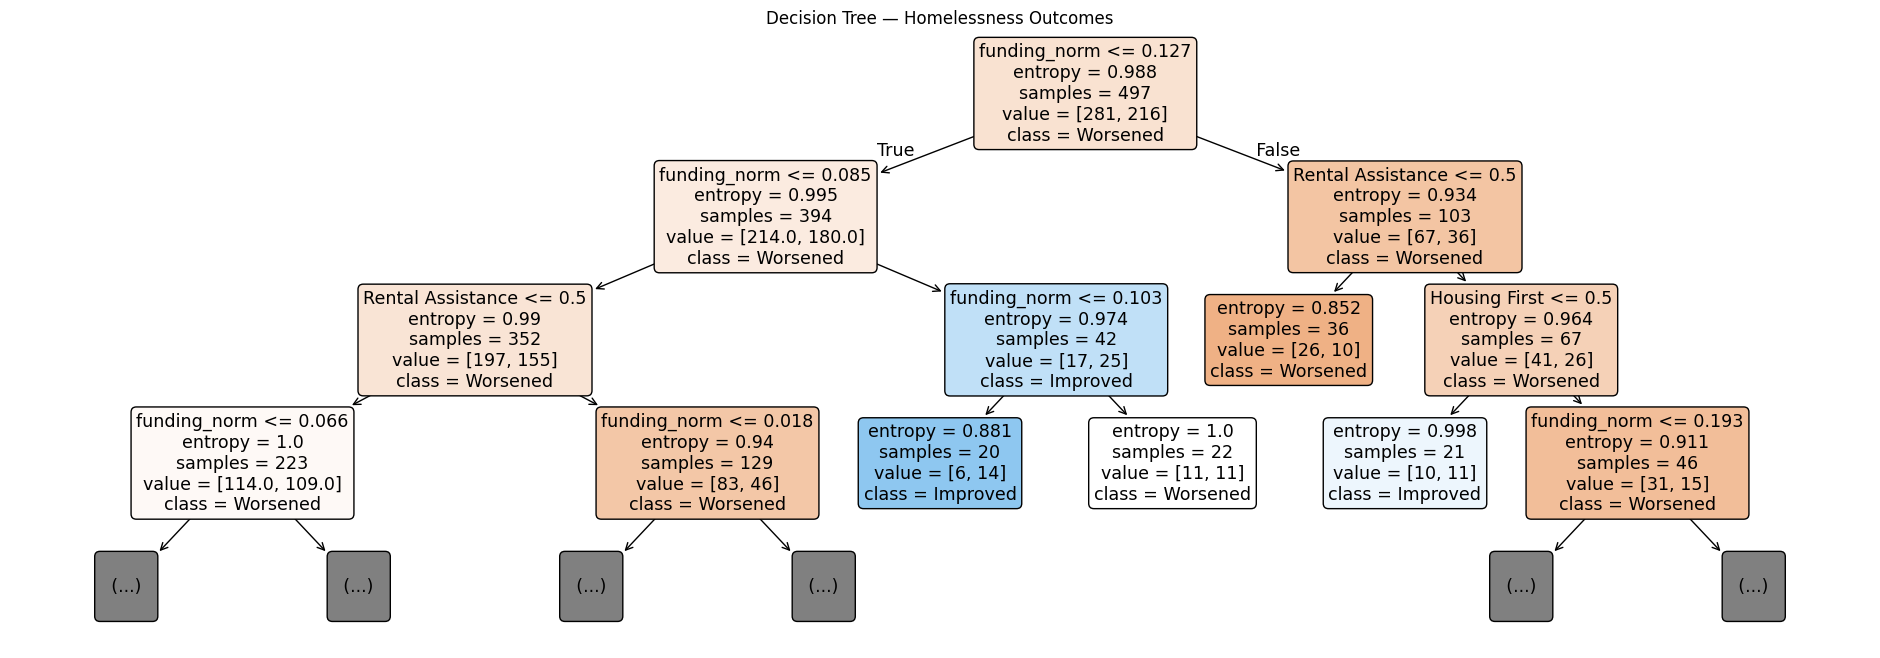

In [62]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 8))
plot_tree(best_model, feature_names=features, class_names=['Worsened', 'Improved'],
          filled=True, rounded=True, max_depth=3)  # max_depth=3 keeps it readable
plt.title("Decision Tree — Homelessness Outcomes")
plt.savefig("decision_tree.png", dpi=150, bbox_inches='tight')
plt.show()

In [63]:
print(f"Total nodes: {best_model.tree_.node_count}")

Total nodes: 37


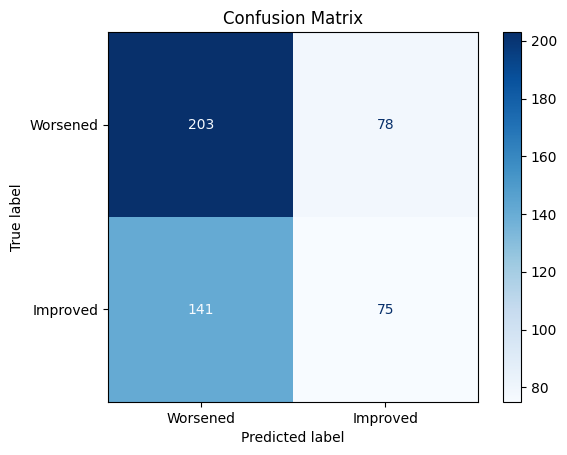

In [64]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(model, X, y, cv=cv)
cm = confusion_matrix(y, y_pred)

ConfusionMatrixDisplay(cm, display_labels=['Worsened', 'Improved']).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [84]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, ParameterGrid
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.dummy import DummyClassifier
from sklearn.base import clone
from tqdm import tqdm


# 1. Start from merged_df
model_df = merged_df.copy()


# 2. Dropp 2014 
model_df = model_df[model_df['Year'] > 2014].copy()


# 3. Create target
model_df['Target'] = (model_df['pct_change_homeless'] < 0).astype(int)


features = [
        'vacancy_rate',
        'ES_share', 'TH_share', 'SH_share',
        'Housing First', 'Rental Assistance', 'Hostile Policies', 'City-Provided Shelter',
        'funding_norm',
        'unsheltered_share',
        'chronic_share',
        'sheltered_share'
        ]

model_df = model_df[['CoC-Code', 'Year', 'Target'] + features].copy()

model_df = model_df.dropna(subset=features + ['Target'])



# 5. Buid Data
X = model_df[features]
y = model_df['Target']

print("Shape:", model_df.shape)
print("\nTarget distribution:")
print(y.value_counts(normalize=True))


# 6. CV Setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# 7. HELPER: Run CV
def run_cv(model, X, y, cv, desc="CV"):
    scores = {
        'Accuracy': [],
        'F1': [],
        'Precision': [],
        'Recall': []
    }

    for train_idx, test_idx in tqdm(cv.split(X, y), total=cv.get_n_splits(), desc=desc, leave=False):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model_clone = clone(model)
        model_clone.fit(X_train, y_train)

        y_pred = model_clone.predict(X_test)

        scores['Accuracy'].append(accuracy_score(y_test, y_pred))
        scores['F1'].append(f1_score(y_test, y_pred, zero_division=0))
        scores['Precision'].append(precision_score(y_test, y_pred, zero_division=0))
        scores['Recall'].append(recall_score(y_test, y_pred, zero_division=0))

    return scores

def summarize_scores(scores):
    return {metric: (np.mean(vals), np.std(vals)) for metric, vals in scores.items()}

def print_scores(name, scores):
    print(f"\n=== {name} ===")
    for metric in scores:
        print(f"{metric}: {np.mean(scores[metric]):.4f} (+/- {np.std(scores[metric]):.4f})")


# 8. Hyperparameter grid
# tuned on F1; classes may have been imbalanced
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, 6, None],
    'min_samples_leaf': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20]
}

grid = list(ParameterGrid(param_grid))
print(f"\nTesting {len(grid)} parameter combinations...")

tuning_results = []

for params in tqdm(grid, desc="Hyperparameter tuning"):
    model = DecisionTreeClassifier(
        random_state=42,
        **params
    )

    scores = run_cv(model, X, y, cv, desc="Inner CV")
    summary = summarize_scores(scores)

    tuning_results.append({
        **params,
        'Accuracy_mean': summary['Accuracy'][0],
        'Accuracy_std': summary['Accuracy'][1],
        'F1_mean': summary['F1'][0],
        'F1_std': summary['F1'][1],
        'Precision_mean': summary['Precision'][0],
        'Recall_mean': summary['Recall'][0]
    })

tuning_df = pd.DataFrame(tuning_results).sort_values(
    by=['F1_mean', 'Accuracy_mean'],
    ascending=False
).reset_index(drop=True)

print("\n=== Top 10 Hyperparameter Settings ===")
print(tuning_df.head(10).to_string(index=False))

best_params = tuning_df.iloc[0][
    ['criterion', 'max_depth', 'min_samples_leaf', 'min_samples_split']
].to_dict()

# convert pandas NaN back to Python None
if pd.isna(best_params['max_depth']):
    best_params['max_depth'] = None
else:
    best_params['max_depth'] = int(best_params['max_depth'])

best_params['min_samples_leaf'] = int(best_params['min_samples_leaf'])
best_params['min_samples_split'] = int(best_params['min_samples_split'])

print("\nBest params:")
print(best_params)

best_model = DecisionTreeClassifier(
    random_state=42,
    criterion=best_params['criterion'],
    max_depth=best_params['max_depth'],
    min_samples_leaf=best_params['min_samples_leaf'],
    min_samples_split=best_params['min_samples_split'],
)

best_scores = run_cv(best_model, X, y, cv, desc="Best Tree CV")
print_scores("Best Decision Tree Classifier", best_scores)


# 10. Dummy baseline
dummy = DummyClassifier(strategy='most_frequent')
dummy_scores = run_cv(dummy, X, y, cv, desc="Dummy CV")
print_scores("Dummy Baseline", dummy_scores)


# 11. Final best model
print("\nFitting best full model...")
best_model.fit(X, y)
print("Done.")

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n=== Feature Importances ===")
display(importance_df)


# 12. Improvement over baseline
tree_acc = np.mean(best_scores['Accuracy'])
dummy_acc = np.mean(dummy_scores['Accuracy'])

print("\n=== Improvement over Baseline ===")
if dummy_acc != 0:
    acc_lift = (tree_acc - dummy_acc) / dummy_acc * 100
    print(f"Accuracy lift: {acc_lift:.1f}%")
else:
    print("Dummy baseline accuracy was 0, cannot compute lift.")

Shape: (497, 15)

Target distribution:
Target
0    0.565392
1    0.434608
Name: proportion, dtype: float64

Testing 192 parameter combinations...


Hyperparameter tuning: 100%|██████████| 192/192 [00:04<00:00, 43.09it/s]



=== Top 10 Hyperparameter Settings ===
criterion  max_depth  min_samples_leaf  min_samples_split  Accuracy_mean  Accuracy_std  F1_mean   F1_std  Precision_mean  Recall_mean
  entropy        NaN                20                  2       0.617778      0.052024 0.577737 0.057804        0.577297     0.615751
  entropy        NaN                20                  5       0.617778      0.052024 0.577737 0.057804        0.577297     0.615751
  entropy        NaN                20                 10       0.617778      0.052024 0.577737 0.057804        0.577297     0.615751
  entropy        NaN                20                 20       0.617778      0.052024 0.577737 0.057804        0.577297     0.615751
     gini        NaN                10                  2       0.639960      0.046865 0.561552 0.034452        0.606990     0.527696
     gini        NaN                10                  5       0.639960      0.046865 0.561552 0.034452        0.606990     0.527696
     gini        NaN  


=== Best Decision Tree Classifier ===
Accuracy: 0.6178 (+/- 0.0520)
F1: 0.5777 (+/- 0.0578)
Precision: 0.5773 (+/- 0.0876)
Recall: 0.6158 (+/- 0.1320)



=== Dummy Baseline ===
Accuracy: 0.5654 (+/- 0.0032)
F1: 0.0000 (+/- 0.0000)
Precision: 0.0000 (+/- 0.0000)
Recall: 0.0000 (+/- 0.0000)

Fitting best full model...
Done.

=== Feature Importances ===


,Feature,Importance
11,sheltered_share,0.396330
2,TH_share,0.179588
0,vacancy_rate,0.129797
7,City-Provided Shelter,0.076225
10,chronic_share,0.064786
8,funding_norm,0.058682
9,unsheltered_share,0.042361
3,SH_share,0.030066
1,ES_share,0.022165
4,Housing First,0.000000



=== Improvement over Baseline ===
Accuracy lift: 9.3%


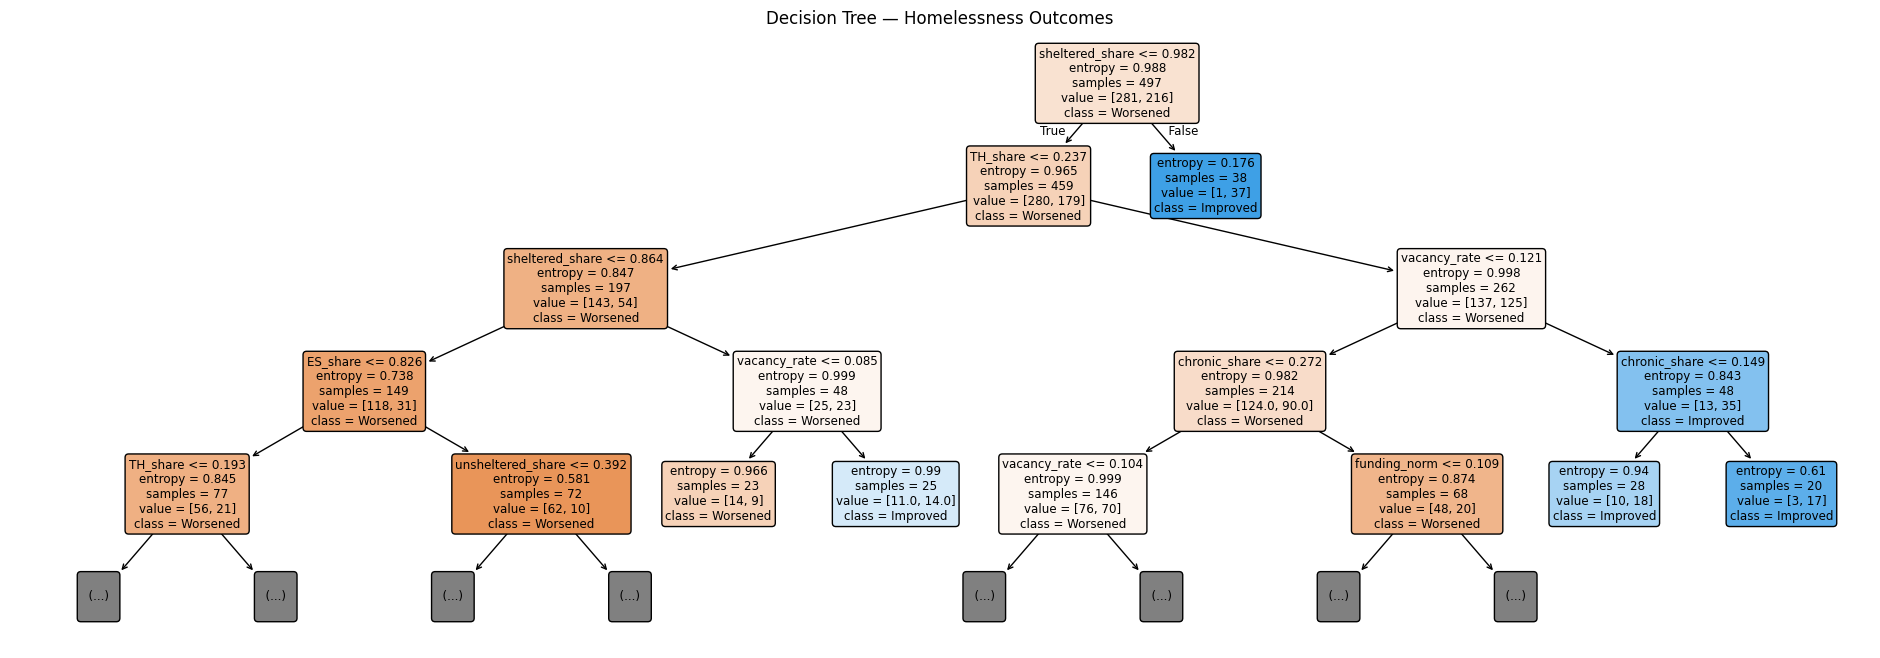

In [88]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 8))
plot_tree(best_model, feature_names=features, class_names=['Worsened', 'Improved'],
          filled=True, rounded=True, max_depth=4)  # max_depth=3 keeps it readable
plt.title("Decision Tree — Homelessness Outcomes")
plt.savefig("decision_tree.png", dpi=150, bbox_inches='tight')
plt.show()

In [89]:
print(f"Total nodes: {best_model.tree_.node_count}")

Total nodes: 37


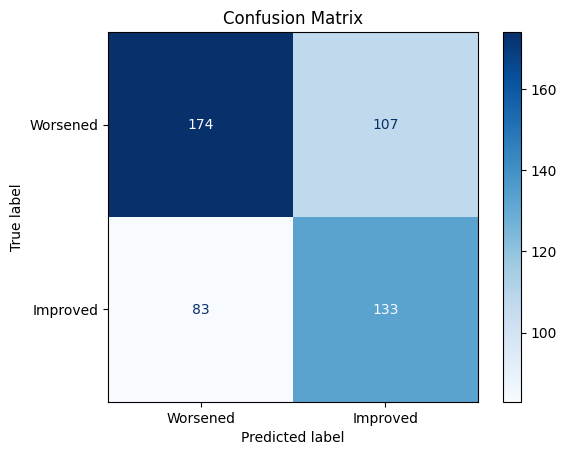

In [90]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(model, X, y, cv=cv)
cm = confusion_matrix(y, y_pred)

ConfusionMatrixDisplay(cm, display_labels=['Worsened', 'Improved']).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix_2.png", dpi=150)
plt.show()